# 10. FreeSurfer Stats Prediction

This notebook trains a multi-head stats-prediction model from the pretrained 3D TransUNet segmentation checkpoints.

Workflow:

1. Verify/download OpenNeuro `stats/*.stats` files into `data/openneuro_stats_cache`.
2. Build train/val/test rows using the same v5-v7 split manifest as `04_train.ipynb` and the v8 split used by `05_train_freesurfer_versions.ipynb`.
3. Parse `.stats` targets into a fixed matrix with masked missing targets.
4. Train one all-data base stats model.
5. Fine-tune from that base model for FS v6, v7, and v8. FS v5 remains in the all-data base stage only because the local HCP stats targets are unavailable.
6. Report and plot split/group metrics.

Target policy is intentionally focused: volumetric tables contribute `Volume_mm3`; aparc tables contribute `NumVert`, `SurfArea`, `GrayVol`, `ThickAvg`, `ThickStd`, `MeanCurv`, `GausCurv`, `FoldInd`, and `CurvInd`; FreeSurfer `# Measure` entries are treated as global targets.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from scalesurfer.config import SEED
from scalesurfer.stats import (
    build_openneuro_stats_rows,
    build_target_long_table,
    build_target_matrix,
    build_v8_stats_rows,
    columns_by_group,
    combine_sample_rows,
    derive_fs_major_by_dataset_from_checkpoints,
    load_split,
    save_json,
    sanitize_target_matrix,
    select_target_columns,
    measure_for_target,
    target_is_supported,
    target_normalization,
    train_stats_stage,
)

BASE_PATH = Path('/home/rph/scalesurfer')
DATA_PATH = BASE_PATH / 'data'
OUT_ROOT = DATA_PATH / 'stats_prediction'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_TENSORS_ROOT = DATA_PATH / 'tensors'
LOCAL_V8_TENSORS_ROOT = DATA_PATH / 'tensors_gcloud'
LOCAL_V8_STATS_ROOT = DATA_PATH / 'fs8_freesurfer_stats_cache'
OPENNEURO_STATS_CACHE_ROOT = DATA_PATH / 'openneuro_stats_cache' / 'files'

SPLIT_MANIFEST_PATH = BASE_PATH / 'docs/notebooks/01_volume/04_train_split_manifest.json'

SEGMENTATION_CHECKPOINTS = {
    'base': BASE_PATH / 'docs/notebooks/01_volume/checkpoints/transunet3d_best.pt',
    5: BASE_PATH / 'docs/notebooks/01_volume/checkpoints_fsv5/fsv5_20260421_015634/transunet3d_best.pt',
    6: BASE_PATH / 'docs/notebooks/01_volume/checkpoints_fsv6/fsv6_20260421_050137/transunet3d_best.pt',
    7: BASE_PATH / 'docs/notebooks/01_volume/checkpoints_fsv7/fsv7_20260422_022504/transunet3d_best.pt',
    8: BASE_PATH / 'docs/notebooks/01_volume/checkpoints_fsv8/fsv8_20260421_152924/transunet3d_best.pt',
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('out:', OUT_ROOT)


device: cuda
out: /home/rph/scalesurfer/data/stats_prediction


## 1. Download OpenNeuro Stats

The inventory and downloader are cache-first. Existing manifest files and cached `stats/*.stats` files are reused; set the `FORCE_*` flags below only when you intentionally want to refresh them.

In [2]:
FORCE_OPENNEURO_INVENTORY = False
FORCE_OPENNEURO_DOWNLOAD = False

inventory_paths = {
    'subject_inventory': OUT_ROOT / 'openneuro_stats_subject_inventory.csv',
    'download_manifest': OUT_ROOT / 'openneuro_stats_download_manifest.csv',
    'dataset_summary': OUT_ROOT / 'openneuro_stats_dataset_summary.csv',
}
download_report_path = OUT_ROOT / 'openneuro_stats_download_report.csv'

inventory_cmd = [
    sys.executable,
    str(BASE_PATH / 'scripts/inventory_openneuro_stats.py'),
    '--tensor-root', str(LOCAL_TENSORS_ROOT),
    '--out-dir', str(OUT_ROOT),
    '--max-workers', '4',
]

download_cmd = [
    sys.executable,
    str(BASE_PATH / 'scripts/download_openneuro_stats.py'),
    '--manifest', str(inventory_paths['download_manifest']),
    '--cache-root', str(OPENNEURO_STATS_CACHE_ROOT),
    '--report', str(download_report_path),
    '--max-workers', '32',
]

def cached_path_for_key(s3_key: str) -> Path:
    return OPENNEURO_STATS_CACHE_ROOT / str(s3_key)

def missing_manifest_cache_paths(manifest_df: pd.DataFrame) -> list[Path]:
    missing = []
    for row in manifest_df.itertuples(index=False):
        s3_key = getattr(row, 's3_key')
        local_cache_path = getattr(row, 'local_cache_path', None)
        candidates = []
        if isinstance(local_cache_path, str) and local_cache_path:
            candidates.append(Path(local_cache_path))
        candidates.append(cached_path_for_key(str(s3_key)))
        if not any(path.exists() for path in candidates):
            missing.append(candidates[-1])
    return missing

missing_inventory = [path for path in inventory_paths.values() if not path.exists()]
if FORCE_OPENNEURO_INVENTORY or missing_inventory:
    print('running OpenNeuro stats inventory; missing:', [str(path) for path in missing_inventory])
    subprocess.run(inventory_cmd, check=True, cwd=BASE_PATH)
else:
    print('using cached OpenNeuro stats inventory files')

manifest = pd.read_csv(inventory_paths['download_manifest'])
missing_cached_stats = missing_manifest_cache_paths(manifest)
if FORCE_OPENNEURO_DOWNLOAD or missing_cached_stats:
    print(f'running OpenNeuro stats download; missing cached stats: {len(missing_cached_stats)}')
    subprocess.run(download_cmd, check=True, cwd=BASE_PATH)
else:
    print(f'using cached OpenNeuro stats files: {len(manifest)} / {len(manifest)} present')


using cached OpenNeuro stats inventory files
using cached OpenNeuro stats files: 26400 / 26400 present


In [3]:
manifest = pd.read_csv(inventory_paths['download_manifest'])
report = pd.read_csv(download_report_path) if download_report_path.exists() else pd.DataFrame()
missing_cached_stats = missing_manifest_cache_paths(manifest)
local_stats_count = sum(1 for _ in OPENNEURO_STATS_CACHE_ROOT.rglob('*.stats'))

print('manifest rows:', len(manifest))
print('local cached .stats files:', local_stats_count)
print('manifest files missing from cache:', len(missing_cached_stats))
if missing_cached_stats:
    print('first missing paths:', [str(path) for path in missing_cached_stats[:5]])
if not report.empty:
    display(report['status'].value_counts(dropna=False).rename_axis('status').reset_index(name='n'))

display(pd.read_csv(inventory_paths['dataset_summary']))


manifest rows: 26400
local cached .stats files: 26400
manifest files missing from cache: 0


,dataset,n_tensor_subjects,n_complete_required,n_any_stats_for_tensor_roots,openneuro_object_count,openneuro_orig_mgz_count,openneuro_aparc_aseg_mgz_count,openneuro_stats_key_count
0,ds001734,117,117,117,48509,122,119,2111
1,ds002041,25,25,25,11223,27,27,650
2,ds002547,26,26,26,13344,29,28,473
3,ds002785,216,216,216,125408,219,218,3893
4,ds002790,226,226,226,117523,229,228,4073
5,ds002799,26,25,25,16825,28,28,449
6,ds003097,928,928,928,394526,931,930,16709
7,ds003354,8,8,8,5374,10,10,144
8,ds003495,24,24,24,12513,26,26,432
9,ds003633,11,11,11,7521,13,13,198


## 2. Build Supervised Rows

For v5-v7, this preserves the split manifest from `04_train.ipynb` and assigns FreeSurfer major versions from the local versioned segmentation checkpoints. For v8, it uses the reproducible v8 split from `data/tensors_gcloud`.


In [4]:
REBUILD_SAMPLE_TABLE = False

fs_version_map_path = OUT_ROOT / 'fs_major_by_dataset_from_checkpoints.json'
samples_path = OUT_ROOT / 'stats_samples.csv'

if not REBUILD_SAMPLE_TABLE and fs_version_map_path.exists():
    fs_major_by_dataset = {k: int(v) for k, v in json.loads(fs_version_map_path.read_text()).items()}
    print('loaded cached FS-version map:', fs_version_map_path)
else:
    fs_major_by_dataset = derive_fs_major_by_dataset_from_checkpoints(
        {k: v for k, v in SEGMENTATION_CHECKPOINTS.items() if isinstance(k, int) and k in {5, 6, 7}}
    )
    save_json(fs_version_map_path, fs_major_by_dataset)
    print('wrote FS-version map:', fs_version_map_path)

print('datasets with recovered FS major:', len(fs_major_by_dataset))
display(pd.Series(fs_major_by_dataset).rename('fs_major').value_counts().sort_index().reset_index(name='n_datasets'))

if not REBUILD_SAMPLE_TABLE and samples_path.exists():
    samples = pd.read_csv(samples_path)
    print('loaded cached supervised rows:', samples_path)
else:
    base_split = load_split(SPLIT_MANIFEST_PATH)
    openneuro_rows = build_openneuro_stats_rows(
        split=base_split,
        tensor_root=LOCAL_TENSORS_ROOT,
        stats_cache_root=OPENNEURO_STATS_CACHE_ROOT,
        fs_major_by_dataset=fs_major_by_dataset,
    )
    v8_rows = build_v8_stats_rows(
        tensors_root=LOCAL_V8_TENSORS_ROOT,
        stats_root=LOCAL_V8_STATS_ROOT,
        seed=SEED,
    )
    samples = combine_sample_rows(openneuro_rows, v8_rows)
    samples.to_csv(samples_path, index=False)
    print('wrote supervised rows:', samples_path)

display(samples.groupby(['fs_major', 'split']).size().unstack(fill_value=0))
display(samples.groupby(['source', 'fs_major']).size().reset_index(name='n'))


loaded cached FS-version map: /home/rph/scalesurfer/data/stats_prediction/fs_major_by_dataset_from_checkpoints.json
datasets with recovered FS major: 52


,fs_major,n_datasets
0,5,1
1,6,22
2,7,29


loaded cached supervised rows: /home/rph/scalesurfer/data/stats_prediction/stats_samples.csv


split,test,train,val
fs_major,,,
5,3,21,3
6,201,1592,202
7,111,898,111
8,48,386,48


,source,fs_major,n
0,fs8,8,482
1,openneuro,5,27
2,openneuro,6,1995
3,openneuro,7,1120


## 3. Parse Targets

The wide target matrix can be loaded from cache after the first build. The long table is optional because it is large; keep `WRITE_LONG_TARGETS = False` unless you need row-level auditing.


In [5]:
import numpy as np

REBUILD_TARGET_CACHE = False
REBUILD_TARGET_SELECTION = False
WRITE_LONG_TARGETS = False

TARGET_CACHE_TAG = 'canonical_aparc_clean_v5_sum_poolstats'
MIN_TRAIN_NONMISSING = 10
MIN_TRAIN_STD = 1e-6

EXCLUDED_TARGET_STATS_NAMES = {'aparc+aseg'}
APPLY_ROBUST_TARGET_OUTLIER_MASK = True
ROBUST_OUTLIER_DEFAULT_Z_MAX = None
ROBUST_OUTLIER_Z_MAX_BY_MEASURE = {
    'Volume_mm3': 100.0,
    'GausCurv': 50.0,
    'FoldInd': 50.0,
    'CurvInd': 50.0,
}

matrix_path = OUT_ROOT / 'stats_targets_matrix.csv'
norm_path = OUT_ROOT / f'stats_target_normalization_{TARGET_CACHE_TAG}.csv'
columns_path = OUT_ROOT / f'stats_columns_by_group_{TARGET_CACHE_TAG}.json'
quality_report_path = OUT_ROOT / f'stats_target_quality_report_{TARGET_CACHE_TAG}.csv'
cleaning_report_path = OUT_ROOT / f'stats_target_cleaning_report_{TARGET_CACHE_TAG}.csv'
long_path = OUT_ROOT / 'stats_targets_long.csv'


def _stats_name_from_target(target: str) -> str:
    return str(target).split(':', 1)[0]


def _measure_from_target_name(target: str) -> str:
    measure = measure_for_target(str(target))
    return measure or 'Global'


def _robust_z(values: pd.Series, *, median: float, mad: float) -> pd.Series:
    if not np.isfinite(mad) or mad <= 0:
        return pd.Series(np.nan, index=values.index, dtype='float64')
    return 0.6745 * (values.astype(float) - float(median)) / float(mad)


def clean_target_matrix_for_training(
    matrix: pd.DataFrame,
    train_sample_ids,
    *,
    excluded_stats_names: set[str],
    apply_outlier_mask: bool,
    zmax_by_measure: dict[str, float],
    default_zmax: float | None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    cleaned = matrix.copy()
    train_ids = [sid for sid in train_sample_ids if sid in cleaned.index]
    train_view = cleaned.reindex(train_ids)
    n_all_before_by_target = cleaned.notna().sum(axis=0)
    n_train_before_by_target = train_view.notna().sum(axis=0)
    rows = []

    target_stats_names = pd.Series({_target: _stats_name_from_target(_target) for _target in cleaned.columns})
    target_measures = pd.Series({_target: _measure_from_target_name(_target) for _target in cleaned.columns})
    excluded_columns = target_stats_names[target_stats_names.isin(excluded_stats_names)].index.tolist()
    if excluded_columns:
        cleaned.loc[:, excluded_columns] = np.nan

    threshold_measures = set(zmax_by_measure)
    if default_zmax is not None:
        threshold_measures.update(target_measures.unique())

    robust_info: dict[str, dict[str, float | int]] = {}
    if apply_outlier_mask and threshold_measures:
        candidate_columns = [
            col for col in cleaned.columns
            if col not in excluded_columns and target_measures[col] in threshold_measures
        ]
        train_view = cleaned.reindex(train_ids)
        for target in candidate_columns:
            measure = target_measures[target]
            zmax = zmax_by_measure.get(measure, default_zmax)
            if zmax is None:
                continue
            values_train = pd.to_numeric(train_view[target], errors='coerce').dropna().astype(float)
            if values_train.size < MIN_TRAIN_NONMISSING:
                continue
            median = float(values_train.median())
            mad = float((values_train - median).abs().median())
            if not np.isfinite(mad) or mad <= 0:
                continue
            rz_train = _robust_z(values_train, median=median, mad=mad).abs()
            n_outlier_train = int((rz_train > float(zmax)).sum())
            values_all = pd.to_numeric(cleaned[target], errors='coerce').dropna().astype(float)
            rz_all = _robust_z(values_all, median=median, mad=mad).abs()
            outlier_index = rz_all[rz_all > float(zmax)].index
            if len(outlier_index):
                cleaned.loc[outlier_index, target] = np.nan
            robust_info[target] = {
                'median': median,
                'mad': mad,
                'n_outlier_train': n_outlier_train,
                'n_outlier_all': int(len(outlier_index)),
                'max_abs_robust_z_train': float(rz_train.max()) if len(rz_train) else np.nan,
            }

    cleaned_train_view = cleaned.reindex(train_ids)
    n_all_after_by_target = cleaned.notna().sum(axis=0)
    n_train_after_by_target = cleaned_train_view.notna().sum(axis=0)

    for target in cleaned.columns:
        measure = target_measures[target]
        info = robust_info.get(target, {})
        values_train = pd.to_numeric(cleaned_train_view[target], errors='coerce').dropna().astype(float)
        if values_train.size:
            median = float(values_train.median())
            mad = float((values_train - median).abs().median())
            q01 = float(values_train.quantile(0.01))
            q50 = float(values_train.quantile(0.50))
            q99 = float(values_train.quantile(0.99))
            zero_frac_train = float((values_train == 0).mean())
        else:
            median = mad = q01 = q50 = q99 = zero_frac_train = np.nan
        rows.append({
            'target': target,
            'stats_name': target_stats_names[target],
            'measure': measure,
            'excluded_stats_name': bool(target in excluded_columns),
            'zmax': zmax_by_measure.get(measure, default_zmax),
            'n_train_before': int(n_train_before_by_target[target]),
            'n_all_before': int(n_all_before_by_target[target]),
            'n_outlier_train': int(info.get('n_outlier_train', 0)),
            'n_outlier_all': int(info.get('n_outlier_all', 0)),
            'n_train_after': int(n_train_after_by_target[target]),
            'n_all_after': int(n_all_after_by_target[target]),
            'zero_frac_train': zero_frac_train,
            'q01_train': q01,
            'q50_train': q50,
            'q99_train': q99,
            'median_train': median,
            'mad_train': mad,
            'max_abs_robust_z_train': float(info.get('max_abs_robust_z_train', np.nan)),
        })

    report = pd.DataFrame(rows)
    return cleaned, report


def summarize_target_cleaning_report(cleaning_report: pd.DataFrame) -> pd.DataFrame:
    if cleaning_report.empty:
        return pd.DataFrame()
    summary = (
        cleaning_report.groupby('measure', as_index=False)
        .agg(
            targets=('target', 'size'),
            excluded_targets=('excluded_stats_name', 'sum'),
            targets_with_outliers=('n_outlier_train', lambda s: int((s > 0).sum())),
            masked_train_values=('n_outlier_train', 'sum'),
            masked_all_values=('n_outlier_all', 'sum'),
            median_zero_frac_train=('zero_frac_train', 'median'),
            max_zero_frac_train=('zero_frac_train', 'max'),
        )
        .sort_values(['masked_train_values', 'excluded_targets', 'targets_with_outliers'], ascending=False)
    )
    display(summary.head(40))
    return summary


if REBUILD_TARGET_CACHE or not matrix_path.exists():
    long_targets = build_target_long_table(samples)
    if WRITE_LONG_TARGETS:
        long_targets.to_csv(long_path, index=False)
        print('wrote long target audit table:', long_path)
    else:
        print('skipping long target audit table; set WRITE_LONG_TARGETS=True to write it')
    raw_target_matrix = build_target_matrix(long_targets)
    raw_target_matrix.to_csv(matrix_path)
    print('wrote raw target matrix:', matrix_path)
else:
    raw_target_matrix = pd.read_csv(matrix_path, index_col=0)
    print('loaded raw target matrix:', matrix_path)

missing_matrix_samples = sorted(set(samples['sample_id']) - set(raw_target_matrix.index))
if missing_matrix_samples:
    raise ValueError(f'cached target matrix is missing {len(missing_matrix_samples)} current samples; rebuild target cache')

target_matrix, target_quality_report = sanitize_target_matrix(raw_target_matrix)
target_matrix, target_cleaning_report = clean_target_matrix_for_training(
    target_matrix,
    samples.loc[samples['split'] == 'train', 'sample_id'].tolist(),
    excluded_stats_names=EXCLUDED_TARGET_STATS_NAMES,
    apply_outlier_mask=APPLY_ROBUST_TARGET_OUTLIER_MASK,
    zmax_by_measure=ROBUST_OUTLIER_Z_MAX_BY_MEASURE,
    default_zmax=ROBUST_OUTLIER_DEFAULT_Z_MAX,
)
target_quality_report.to_csv(quality_report_path, index=False)
target_cleaning_report.to_csv(cleaning_report_path, index=False)
print('wrote target quality report:', quality_report_path)
print('wrote target cleaning report:', cleaning_report_path)

selection_cache_ready = norm_path.exists() and columns_path.exists()
if REBUILD_TARGET_SELECTION or not selection_cache_ready:
    selected_columns = select_target_columns(
        target_matrix,
        samples.loc[samples['split'] == 'train', 'sample_id'].tolist(),
        min_train_nonmissing=MIN_TRAIN_NONMISSING,
        min_train_std=MIN_TRAIN_STD,
    )
    target_stats = target_normalization(
        target_matrix,
        samples.loc[samples['split'] == 'train', 'sample_id'].tolist(),
        selected_columns,
    )
    cols_by_group = columns_by_group(selected_columns)
    target_stats.to_csv(norm_path, index=False)
    save_json(columns_path, cols_by_group)
    print('wrote target selection cache files:', norm_path, columns_path)
else:
    target_stats = pd.read_csv(norm_path)
    cols_by_group = json.loads(columns_path.read_text())
    print('loaded target selection cache files:', norm_path, columns_path)

selected_targets = [target for targets in cols_by_group.values() for target in targets]
unsupported_selected = [target for target in selected_targets if not target_is_supported(target)]
pial_selected = [target for target in selected_targets if '.aparc.pial:' in target]
excluded_selected = [target for target in selected_targets if _stats_name_from_target(target) in EXCLUDED_TARGET_STATS_NAMES]
if unsupported_selected:
    raise ValueError(f'Unsupported selected targets found: {unsupported_selected[:10]}')
if pial_selected:
    raise ValueError(f'Pial aparc selected targets found: {pial_selected[:10]}')
if excluded_selected:
    raise ValueError(f'Excluded stats-name targets selected: {excluded_selected[:10]}')

target_stats = target_stats.copy()
target_stats['measure'] = target_stats['target'].map(measure_for_target).replace('', 'Global')
target_cleaning_summary = summarize_target_cleaning_report(target_cleaning_report)

print('target cache tag:', TARGET_CACHE_TAG)
print('raw target_matrix:', raw_target_matrix.shape)
print('sanitized + cleaned target_matrix:', target_matrix.shape)
print('selected targets:', sum(len(v) for v in cols_by_group.values()))
print('excluded stats names:', sorted(EXCLUDED_TARGET_STATS_NAMES))
print('robust outlier mask:', APPLY_ROBUST_TARGET_OUTLIER_MASK, ROBUST_OUTLIER_Z_MAX_BY_MEASURE)
display(pd.Series({k: len(v) for k, v in cols_by_group.items()}).rename_axis('group').reset_index(name='n_targets'))
display(target_stats.groupby('group').agg(n_targets=('target', 'size'), median_n_train=('n_train', 'median')))
display(target_stats.groupby(['group', 'measure']).size().reset_index(name='n_targets'))
if not target_quality_report.empty:
    display(
        target_quality_report
        .groupby(['supported', 'measure'], dropna=False)
        .agg(n_targets=('target', 'size'), n_removed=('n_removed', 'sum'))
        .reset_index()
        .sort_values(['supported', 'n_removed'], ascending=[True, False])
        .head(40)
    )
display(
    target_cleaning_report
    .sort_values(['excluded_stats_name', 'n_outlier_train', 'zero_frac_train'], ascending=[False, False, False])
    .head(40)
)


loaded raw target matrix: /home/rph/scalesurfer/data/stats_prediction/stats_targets_matrix.csv
wrote target quality report: /home/rph/scalesurfer/data/stats_prediction/stats_target_quality_report_canonical_aparc_clean_v5_sum_poolstats.csv
wrote target cleaning report: /home/rph/scalesurfer/data/stats_prediction/stats_target_cleaning_report_canonical_aparc_clean_v5_sum_poolstats.csv
loaded target selection cache files: /home/rph/scalesurfer/data/stats_prediction/stats_target_normalization_canonical_aparc_clean_v5_sum_poolstats.csv /home/rph/scalesurfer/data/stats_prediction/stats_columns_by_group_canonical_aparc_clean_v5_sum_poolstats.json


,measure,targets,excluded_targets,targets_with_outliers,masked_train_values,masked_all_values,median_zero_frac_train,max_zero_frac_train
8,FoldInd,68,0,66,767,943,0.000000,0.000366
27,Volume_mm3,1954,1810,2,390,490,0.000000,1.000000
7,CurvInd,68,0,25,73,86,0.000000,0.000365
9,GausCurv,68,0,23,30,32,0.000000,0.000000
0,BrainSegVol,6,0,0,0,0,0.000000,0.000000
1,BrainSegVol-to-eTIV,1,0,0,0,0,0.000000,0.000000
2,BrainSegVolNotVent,6,0,0,0,0,0.000000,0.000000
3,BrainSegVolNotVentSurf,6,0,0,0,0,0.000000,0.000000
4,CerebralWhiteMatterVol,3,0,0,0,0,0.000000,0.000000
5,CortexVol,6,0,0,0,0,0.000000,0.000000


target cache tag: canonical_aparc_clean_v5_sum_poolstats
raw target_matrix: (3624, 2656)
sanitized + cleaned target_matrix: (3624, 2656)
selected targets: 795
excluded stats names: ['aparc+aseg']
robust outlier mask: True {'Volume_mm3': 100.0, 'GausCurv': 50.0, 'FoldInd': 50.0, 'CurvInd': 50.0}


,group,n_targets
0,aseg,119
1,global,64
2,lh_aparc,306
3,rh_aparc,306


,n_targets,median_n_train
group,,
aseg,119,2896.0
global,64,2143.5
lh_aparc,306,2739.0
rh_aparc,306,2739.0


,group,measure,n_targets
0,aseg,Volume_mm3,119
1,global,BrainSegVol,4
2,global,BrainSegVol-to-eTIV,1
3,global,BrainSegVolNotVent,4
4,global,BrainSegVolNotVentSurf,4
5,global,CerebralWhiteMatterVol,3
6,global,CortexVol,4
7,global,MaskVol,3
8,global,MaskVol-to-eTIV,1
9,global,MeanThickness,2


,supported,measure,n_targets,n_removed
4,False,MeanThickness,2,7230
5,False,NumVert,2,7230
6,False,PialSurfArea,2,7230
0,False,BrainSegVol,2,4470
1,False,BrainSegVolNotVent,2,4470
2,False,BrainSegVolNotVentSurf,2,4470
7,False,SupraTentorialVol,2,4470
8,False,SupraTentorialVolNotVent,2,4470
9,False,eTIV,2,4470
3,False,CortexVol,2,408


,target,stats_name,measure,excluded_stats_name,zmax,n_train_before,n_all_before,n_outlier_train,n_outlier_all,n_train_after,n_all_after,zero_frac_train,q01_train,q50_train,q99_train,median_train,mad_train,max_abs_robust_z_train
0,aparc+aseg:3rd-Ventricle:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,aparc+aseg:4th-Ventricle:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,aparc+aseg:5th-Ventricle:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,aparc+aseg:AIPS_AIP_l:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,aparc+aseg:AIPS_AIP_r:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,aparc+aseg:AIPS_VIP_l:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,aparc+aseg:AIPS_VIP_r:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,aparc+aseg:Abducens_nucleus_6N:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,aparc+aseg:Accessory-Basal-nucleus:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,aparc+aseg:Accessory_nerve_nucleus_11N:Volume_mm3,aparc+aseg,Volume_mm3,True,100.0,386,482,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Training Configuration

Default training freezes the pretrained encoder and learns the stats heads. Fine-tune stages instantiate the corresponding versioned segmentation encoder, then load the base all-data stats heads.


In [6]:
RUN_TRAINING = False
FORCE_RETRAIN = False

STATS_RUN_ROOT = OUT_ROOT / f'checkpoints_stats_{TARGET_CACHE_TAG}'
STATS_RUN_ROOT.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE_DIR = OUT_ROOT / f'pooled_feature_cache_{TARGET_CACHE_TAG}'
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

POOL_FEATURES = ('enc1', 'enc2', 'enc3', 'enc4', 'z')
HIDDEN = 512
DROPOUT = 0.1
FREEZE_ENCODER = True
LOAD_BASE_ENCODER_FOR_FINETUNES = False

CACHE_FROZEN_ENCODER_FEATURES = FREEZE_ENCODER
# USE_AMP = DEVICE == 'cuda'

USE_AMP = False
# CACHE_FROZEN_ENCODER_FEATURES = False


BASE_EPOCHS = 100
FINETUNE_EPOCHS = 100
BATCH_SIZE = 64 if CACHE_FROZEN_ENCODER_FEATURES else (2 if DEVICE == 'cuda' else 1)
FEATURE_BATCH_SIZE = 2 if DEVICE == 'cuda' else 1
CPU_COUNT = os.cpu_count() or 1
NUM_WORKERS = min(8, max(2, CPU_COUNT // 4)) if DEVICE == 'cuda' else 0
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 2 if NUM_WORKERS > 0 else None
BASE_LR = 3e-5
FINETUNE_LR = 5e-5
WEIGHT_DECAY = 1e-4

# Robust regression objective on normalized targets.
# Large residuals are down-weighted by Huber loss instead of deleting target values.
HUBER_DELTA = 1.0
LOSS_REDUCTION = 'group_mean'
GROUP_LOSS_WEIGHTS = None

BASE_STATS_CHECKPOINT_OVERRIDE = None
FINETUNE_FS_MAJORS = (6, 7, 8)

def latest_stage_checkpoint(stage: str) -> Path | None:
    candidates = sorted(
        STATS_RUN_ROOT.glob(f'{stage}_*/stats_model_best.pt'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else None

print('run root:', STATS_RUN_ROOT)
print('feature cache:', FEATURE_CACHE_DIR)
print('freeze encoder:', FREEZE_ENCODER)
print('cache frozen encoder features:', CACHE_FROZEN_ENCODER_FEATURES)
print('amp:', USE_AMP)
print('batch size:', BATCH_SIZE)
print('feature extraction batch size:', FEATURE_BATCH_SIZE)
print('num workers:', NUM_WORKERS)
print('prefetch factor:', PREFETCH_FACTOR)
print('finetunes load base encoder:', LOAD_BASE_ENCODER_FOR_FINETUNES)
print('force retrain:', FORCE_RETRAIN)
print('fine-tune FS majors:', FINETUNE_FS_MAJORS)
print('loss reduction:', LOSS_REDUCTION)


run root: /home/rph/scalesurfer/data/stats_prediction/checkpoints_stats_canonical_aparc_clean_v5_sum_poolstats
feature cache: /home/rph/scalesurfer/data/stats_prediction/pooled_feature_cache_canonical_aparc_clean_v5_sum_poolstats
freeze encoder: True
cache frozen encoder features: True
amp: False
batch size: 64
feature extraction batch size: 2
num workers: 4
prefetch factor: 2
finetunes load base encoder: False
force retrain: False
fine-tune FS majors: (6, 7, 8)
loss reduction: group_mean


In [7]:
def split_frames(frame: pd.DataFrame, fs_major: int | None = None):
    subset = frame if fs_major is None else frame[frame['fs_major'] == int(fs_major)]
    train_df = subset[subset['split'] == 'train'].copy()
    val_df = subset[subset['split'] == 'val'].copy()
    test_df = subset[subset['split'] == 'test'].copy()
    return train_df, val_df, test_df

train_all, val_all, test_all = split_frames(samples)
print('all-data split:', len(train_all), len(val_all), len(test_all))
for major in sorted(samples['fs_major'].dropna().astype(int).unique()):
    tr, va, te = split_frames(samples, major)
    suffix = ' fine-tune' if major in FINETUNE_FS_MAJORS else ' base-only'
    print(f'FS v{major}{suffix}: train={len(tr)} val={len(va)} test={len(te)}')


all-data split: 2897 364 363
FS v5 base-only: train=21 val=3 test=3
FS v6 fine-tune: train=1592 val=202 test=201
FS v7 fine-tune: train=898 val=111 test=111
FS v8 fine-tune: train=386 val=48 test=48


## Speed Sanity Check

Optional quick benchmark for the current machine. Keep this off during normal runs; enable it when tuning worker count, feature batch size, or AMP.

In [8]:
RUN_SPEED_CHECK = False

if RUN_SPEED_CHECK:
    import time
    from scalesurfer.stats import build_stats_model, make_stats_loader, run_stats_epoch

    bench_df = train_all.head(min(8, len(train_all))).copy()
    bench_cols = {group: cols[: min(64, len(cols))] for group, cols in cols_by_group.items()}
    bench_model, _ = build_stats_model(
        segmentation_checkpoint=SEGMENTATION_CHECKPOINTS['base'],
        out_dims={group: len(cols) for group, cols in bench_cols.items()},
        pool_features=POOL_FEATURES,
        hidden=HIDDEN,
        dropout=DROPOUT,
        device=DEVICE,
    )
    bench_model.freeze_encoder(FREEZE_ENCODER)
    bench_loader = make_stats_loader(
        bench_df,
        target_matrix,
        target_stats,
        bench_cols,
        batch_size=FEATURE_BATCH_SIZE if CACHE_FROZEN_ENCODER_FEATURES else BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
    )
    t0 = time.perf_counter()
    loss = run_stats_epoch(
        bench_model,
        bench_loader,
        optimizer=None,
        device=DEVICE,
        desc='speed check forward',
        delta=HUBER_DELTA,
        amp=USE_AMP,
    )
    elapsed = time.perf_counter() - t0
    print(f'speed check loss={loss:.4f} samples={len(bench_df)} elapsed={elapsed:.1f}s samples/sec={len(bench_df) / max(elapsed, 1e-6):.3f}')


## 5. Train Base Model On All Data


In [10]:
stage_results = {}
base_stats_checkpoint = Path(BASE_STATS_CHECKPOINT_OVERRIDE) if BASE_STATS_CHECKPOINT_OVERRIDE else None
cached_base_checkpoint = None if FORCE_RETRAIN else latest_stage_checkpoint('stats_base_all')

if RUN_TRAINING and base_stats_checkpoint is None and cached_base_checkpoint is not None:
    base_stats_checkpoint = cached_base_checkpoint
    print('using cached base stats checkpoint:', base_stats_checkpoint)
elif RUN_TRAINING and (FORCE_RETRAIN or base_stats_checkpoint is None):
    base_result = train_stats_stage(
        stage='stats_base_all',
        train_df=train_all,
        val_df=val_all,
        test_df=test_all,
        target_matrix=target_matrix,
        target_stats=target_stats,
        cols_by_group=cols_by_group,
        segmentation_checkpoint=SEGMENTATION_CHECKPOINTS['base'],
        out_dir=STATS_RUN_ROOT,
        init_stats_checkpoint=None,
        load_init_encoder=True,
        pool_features=POOL_FEATURES,
        hidden=HIDDEN,
        dropout=DROPOUT,
        freeze_encoder=FREEZE_ENCODER,
        epochs=BASE_EPOCHS,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
        amp=USE_AMP,
        cache_features=CACHE_FROZEN_ENCODER_FEATURES,
        feature_cache_dir=FEATURE_CACHE_DIR,
        feature_batch_size=FEATURE_BATCH_SIZE,
        lr=BASE_LR,
        weight_decay=WEIGHT_DECAY,
        delta=HUBER_DELTA,
        loss_reduction=LOSS_REDUCTION,
        group_loss_weights=GROUP_LOSS_WEIGHTS,
        device=DEVICE,
    )
    stage_results['base'] = base_result
    base_stats_checkpoint = base_result.checkpoint_path
elif RUN_TRAINING:
    print('using BASE_STATS_CHECKPOINT_OVERRIDE as base stats checkpoint:', base_stats_checkpoint)
else:
    if base_stats_checkpoint is None:
        base_stats_checkpoint = cached_base_checkpoint
    print('Training disabled. Existing base checkpoint:', base_stats_checkpoint)

print('base stats checkpoint:', base_stats_checkpoint)

Training disabled. Existing base checkpoint: /home/rph/scalesurfer/data/stats_prediction/checkpoints_stats_canonical_aparc_clean_v5_sum_poolstats/stats_base_all_20260616_162918/stats_model_best.pt
base stats checkpoint: /home/rph/scalesurfer/data/stats_prediction/checkpoints_stats_canonical_aparc_clean_v5_sum_poolstats/stats_base_all_20260616_162918/stats_model_best.pt


## 6. Fine-Tune Per FreeSurfer Version

Order: FS v6, FS v7, FS v8. FS v5 is not fine-tuned separately unless HCP `.stats` targets become available and the supervised v5 set is rebuilt.

In [11]:
if RUN_TRAINING:
    if base_stats_checkpoint is None:
        raise ValueError('Need a base stats checkpoint before version fine-tuning.')
    for fs_major in FINETUNE_FS_MAJORS:
        stage = f'stats_fsv{fs_major}'
        cached_stage_checkpoint = None if FORCE_RETRAIN else latest_stage_checkpoint(stage)
        if cached_stage_checkpoint is not None:
            print(f'using cached {stage} checkpoint:', cached_stage_checkpoint)
            continue
        train_df, val_df, test_df = split_frames(samples, fs_major)
        if train_df.empty or val_df.empty or test_df.empty:
            print(f'[skip FS v{fs_major}] empty split')
            continue
        result = train_stats_stage(
            stage=stage,
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            target_matrix=target_matrix,
            target_stats=target_stats,
            cols_by_group=cols_by_group,
            segmentation_checkpoint=SEGMENTATION_CHECKPOINTS[fs_major],
            out_dir=STATS_RUN_ROOT,
            init_stats_checkpoint=base_stats_checkpoint,
            load_init_encoder=LOAD_BASE_ENCODER_FOR_FINETUNES,
            pool_features=POOL_FEATURES,
            hidden=HIDDEN,
            dropout=DROPOUT,
            freeze_encoder=FREEZE_ENCODER,
            epochs=FINETUNE_EPOCHS,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            persistent_workers=PERSISTENT_WORKERS,
            prefetch_factor=PREFETCH_FACTOR,
            amp=USE_AMP,
            cache_features=CACHE_FROZEN_ENCODER_FEATURES,
            feature_cache_dir=FEATURE_CACHE_DIR,
            feature_batch_size=FEATURE_BATCH_SIZE,
            lr=FINETUNE_LR,
            weight_decay=WEIGHT_DECAY,
            delta=HUBER_DELTA,
            loss_reduction=LOSS_REDUCTION,
            group_loss_weights=GROUP_LOSS_WEIGHTS,
            device=DEVICE,
        )
        stage_results[f'fsv{fs_major}'] = result
else:
    print('Training disabled. Set RUN_TRAINING=True to run missing version fine-tunes.')


Training disabled. Set RUN_TRAINING=True to run missing version fine-tunes.


## 7. Report Results


In [12]:
def load_existing_summaries(run_root: Path) -> pd.DataFrame:
    rows = []
    for summary_path in sorted(run_root.glob('*/summary.csv')):
        frame = pd.read_csv(summary_path)
        frame['run_dir'] = str(summary_path.parent)
        rows.append(frame)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

if stage_results:
    summary_df = pd.concat([result.summary.assign(run_dir=str(result.run_dir)) for result in stage_results.values()], ignore_index=True)
else:
    summary_df = load_existing_summaries(STATS_RUN_ROOT)

summary_out = OUT_ROOT / 'stats_training_summary.csv'
if not summary_df.empty:
    summary_df.to_csv(summary_out, index=False)
    display(summary_df.sort_values(['stage', 'split', 'group']))
    print('wrote:', summary_out)
else:
    print('No training summaries found yet.')


,stage,best_epoch,best_val_loss,split,group,n_targets,n_values,normalized_mae,median_abs_percent_error,run_dir
0,stats_base_all,99,0.172724,test,aseg,119,39699,0.471478,7.629659,/home/rph/scalesurfer/data/stats_prediction/ch...
1,stats_base_all,99,0.172724,test,global,64,16070,0.212406,1.701832,/home/rph/scalesurfer/data/stats_prediction/ch...
2,stats_base_all,99,0.172724,test,lh_aparc,306,106742,0.456201,8.101014,/home/rph/scalesurfer/data/stats_prediction/ch...
3,stats_base_all,99,0.172724,test,rh_aparc,306,106738,0.456955,7.982770,/home/rph/scalesurfer/data/stats_prediction/ch...
4,stats_base_all,99,0.172724,train,aseg,119,315015,0.473211,7.548016,/home/rph/scalesurfer/data/stats_prediction/ch...
5,stats_base_all,99,0.172724,train,global,64,127673,0.212668,1.807447,/home/rph/scalesurfer/data/stats_prediction/ch...
6,stats_base_all,99,0.172724,train,lh_aparc,306,837725,0.459715,8.048737,/home/rph/scalesurfer/data/stats_prediction/ch...
7,stats_base_all,99,0.172724,train,rh_aparc,306,837654,0.457218,7.954879,/home/rph/scalesurfer/data/stats_prediction/ch...
8,stats_base_all,99,0.172724,val,aseg,119,39776,0.489537,7.375906,/home/rph/scalesurfer/data/stats_prediction/ch...
9,stats_base_all,99,0.172724,val,global,64,15993,0.224019,1.860114,/home/rph/scalesurfer/data/stats_prediction/ch...


wrote: /home/rph/scalesurfer/data/stats_prediction/stats_training_summary.csv


## 8. Plot Results


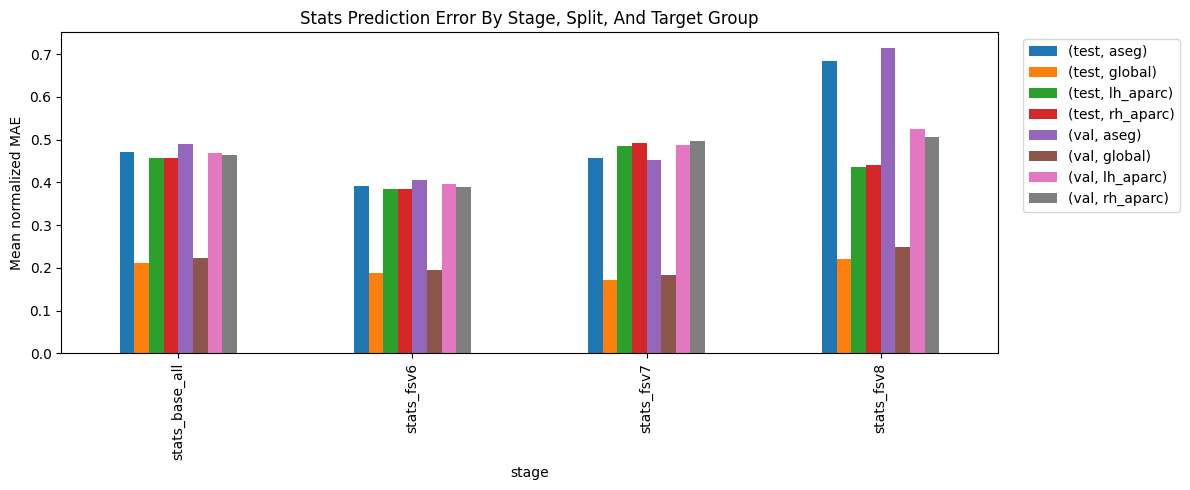

In [13]:
if not summary_df.empty:
    plot_df = summary_df[summary_df['split'].isin(['val', 'test'])].copy()
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot = plot_df.pivot_table(index='stage', columns=['split', 'group'], values='normalized_mae', aggfunc='mean')
    pivot.plot(kind='bar', ax=ax)
    ax.set_ylabel('Mean normalized MAE')
    ax.set_title('Stats Prediction Error By Stage, Split, And Target Group')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    fig.tight_layout()
    fig.savefig(OUT_ROOT / 'stats_training_normalized_mae_by_group.png', dpi=180)
    plt.show()
else:
    print('No summary data to plot yet.')


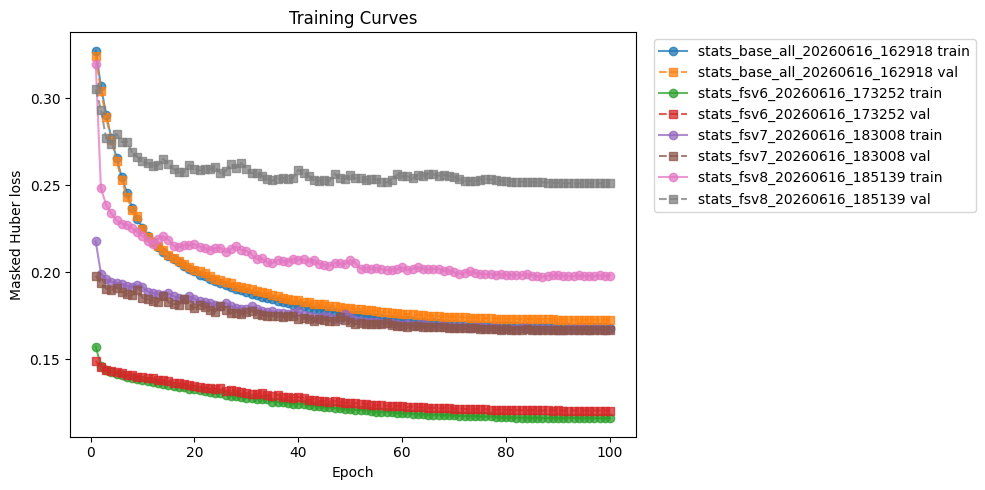

In [14]:
def load_existing_histories(run_root: Path) -> pd.DataFrame:
    rows = []
    for history_path in sorted(run_root.glob('*/history.csv')):
        frame = pd.read_csv(history_path)
        frame['stage'] = history_path.parent.name
        rows.append(frame)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

history_df = (
    pd.concat([result.history.assign(stage=result.stage) for result in stage_results.values()], ignore_index=True)
    if stage_results else load_existing_histories(STATS_RUN_ROOT)
)

if not history_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for stage, frame in history_df.groupby('stage'):
        ax.plot(frame['epoch'], frame['train_loss'], marker='o', alpha=0.75, label=f'{stage} train')
        ax.plot(frame['epoch'], frame['val_loss'], marker='s', alpha=0.75, linestyle='--', label=f'{stage} val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Masked Huber loss')
    ax.set_title('Training Curves')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    fig.tight_layout()
    fig.savefig(OUT_ROOT / 'stats_training_curves.png', dpi=180)
    plt.show()
else:
    print('No history data to plot yet.')


,stage,group,target,n,normalized_mae,median_abs_percent_error
8644,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-entorhinal:Volume_mm3,48,1.706228,151.781822
8643,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-cuneus:Volume_mm3,48,1.632921,70.788319
8701,stats_fsv8_20260616_185139,aseg,wmparc:wm-rh-precentral:Volume_mm3,48,1.504752,28.448191
8654,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-medialorbitofrontal:Volume_mm3,48,1.487639,35.449718
8691,stats_fsv8_20260616_185139,aseg,wmparc:wm-rh-medialorbitofrontal:Volume_mm3,48,1.476533,29.325264
8694,stats_fsv8_20260616_185139,aseg,wmparc:wm-rh-parahippocampal:Volume_mm3,48,1.471790,36.087475
8664,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-precentral:Volume_mm3,48,1.469099,22.125395
8639,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-bankssts:Volume_mm3,48,1.409354,49.763630
8648,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-inferiortemporal:Volume_mm3,48,1.398499,24.666777
8647,stats_fsv8_20260616_185139,aseg,wmparc:wm-lh-inferiorparietal:Volume_mm3,48,1.397319,31.452963


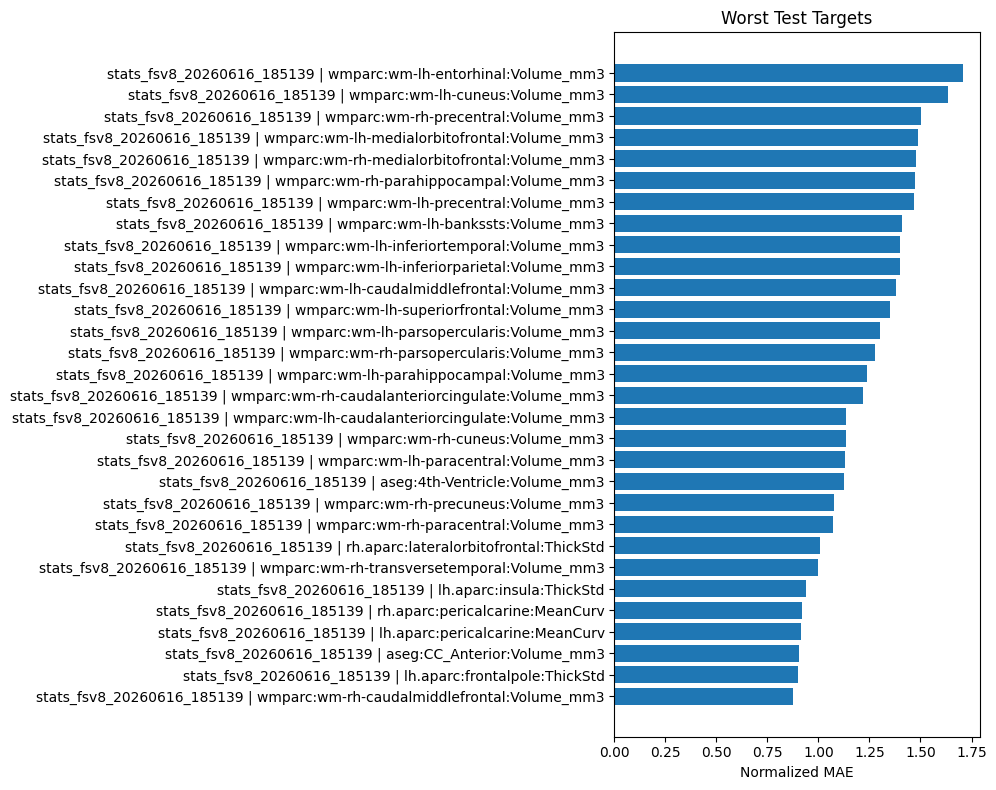

In [15]:
def load_existing_target_metrics(run_root: Path) -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(run_root.glob('*/target_metrics.csv')):
        frame = pd.read_csv(metrics_path)
        frame['stage'] = metrics_path.parent.name
        rows.append(frame)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

target_metrics_df = (
    pd.concat([result.target_metrics.assign(stage=result.stage) for result in stage_results.values()], ignore_index=True)
    if stage_results else load_existing_target_metrics(STATS_RUN_ROOT)
)

if not target_metrics_df.empty:
    top = (
        target_metrics_df[target_metrics_df['split'] == 'test']
        .sort_values('normalized_mae', ascending=False)
        .head(30)
        .copy()
    )
    display(top[['stage', 'group', 'target', 'n', 'normalized_mae', 'median_abs_percent_error']])
    fig, ax = plt.subplots(figsize=(10, 8))
    labels = top['stage'] + ' | ' + top['target'].str.slice(0, 64)
    ax.barh(labels[::-1], top['normalized_mae'][::-1])
    ax.set_xlabel('Normalized MAE')
    ax.set_title('Worst Test Targets')
    fig.tight_layout()
    fig.savefig(OUT_ROOT / 'stats_training_worst_test_targets.png', dpi=180)
    plt.show()
else:
    print('No target metrics to plot yet.')


In [16]:
if stage_results and 'fsv8' in stage_results:
    tm = stage_results['fsv8'].target_metrics
    display(tm[tm['split'] == 'test'])
else:
    print('No in-memory fsv8 result; using saved reports above instead.')


No in-memory fsv8 result; using saved reports above instead.


## 9. Predicted vs FreeSurfer Scatter Plots

Build per-target prediction tables from the latest trained checkpoints, then plot one scatter panel per stats measure type.

In [17]:
import numpy as np

from scalesurfer.stats import (
    build_stats_model,
    load_or_build_pooled_feature_cache,
    load_stats_checkpoint,
    make_stats_feature_loader,
    make_stats_loader,
)

SCATTER_SPLIT = 'test'
SCATTER_USE_VERSIONED_MODELS = True
SCATTER_MAX_POINTS_PER_PANEL = 50_000
SCATTER_COMPARISON_PATH = OUT_ROOT / f'stats_feature_comparison_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.csv'
SCATTER_FIG_PATH = BASE_PATH / 'docs/notebooks/03_inference' / f'stats_feature_predictions_by_measure_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.png'
SCATTER_ROBUST_AXES = True
SCATTER_AXIS_QUANTILES = (0.005, 0.995)
SCATTER_MIN_AXIS_SPAN = 1e-6

MEASURE_ORDER = {
    'Volume_mm3': 0,
    'NumVert': 1,
    'SurfArea': 2,
    'GrayVol': 3,
    'ThickAvg': 4,
    'ThickStd': 5,
    'MeanCurv': 6,
    'GausCurv': 7,
    'FoldInd': 8,
    'CurvInd': 9,
    'Global': 10,
}
MEASURE_LABELS = {
    'Volume_mm3': 'Volume',
    'NumVert': 'Number of vertices',
    'SurfArea': 'Surface area',
    'GrayVol': 'Gray matter volume',
    'ThickAvg': 'Mean thickness',
    'ThickStd': 'Thickness std',
    'MeanCurv': 'Mean curvature',
    'GausCurv': 'Gaussian curvature',
    'FoldInd': 'Folding index',
    'CurvInd': 'Intrinsic curvature index',
    'Global': 'Global measures',
}
MEASURE_UNITS = {
    'Volume_mm3': 'mm^3',
    'NumVert': 'vertices',
    'SurfArea': 'mm^2',
    'GrayVol': 'mm^3',
    'ThickAvg': 'mm',
    'ThickStd': 'mm',
    'MeanCurv': '1/mm',
    'GausCurv': '1/mm^2',
    'FoldInd': 'index',
    'CurvInd': 'index',
    'Global': 'native units',
}


def _measure_unit(measure: str) -> str:
    return MEASURE_UNITS.get(str(measure), 'native units')


def _axis_label(base: str, measure: str) -> str:
    unit = _measure_unit(measure)
    return f'{base} ({unit})' if unit else base


def _stage_from_checkpoint_path(path: Path) -> str:
    name = path.parent.name
    for stage in ('stats_base_all', 'stats_fsv5', 'stats_fsv6', 'stats_fsv7', 'stats_fsv8'):
        if name == stage or name.startswith(stage + '_'):
            return stage
    return name


def _latest_checkpoint_for_stage(stage: str) -> Path | None:
    if 'latest_stage_checkpoint' in globals():
        return latest_stage_checkpoint(stage)
    candidates = sorted(
        STATS_RUN_ROOT.glob(f'{stage}_*/stats_model_best.pt'),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else None


def _segmentation_checkpoint_for_stage(stage: str) -> Path:
    if stage == 'stats_base_all':
        return SEGMENTATION_CHECKPOINTS['base']
    if stage.startswith('stats_fsv'):
        return SEGMENTATION_CHECKPOINTS[int(stage.removeprefix('stats_fsv'))]
    raise KeyError(f'Cannot infer segmentation checkpoint for stage: {stage}')


def _stats_name_from_target_for_plot(target: str) -> str:
    return str(target).split(':', 1)[0]


def _measure_from_target(target: str) -> str:
    parts = str(target).split(':')
    if len(parts) >= 3 and parts[1] == 'global':
        return 'Global'
    return parts[-1] if parts else str(target)


def _region_from_target(target: str) -> str:
    parts = str(target).split(':')
    if len(parts) >= 3 and parts[1] != 'global':
        return parts[1]
    if len(parts) >= 3:
        return parts[2]
    return ''


def _load_feature_payload_from_run_config(model, run_dir: Path, sample_frame: pd.DataFrame):
    config_path = run_dir / 'config.json'
    if not config_path.exists():
        return None
    config = json.loads(config_path.read_text())
    feature_cache_path = config.get('feature_cache_path')
    if not feature_cache_path:
        return None
    feature_cache_path = Path(feature_cache_path)
    if not feature_cache_path.exists():
        return None
    payload = torch.load(feature_cache_path, map_location='cpu')
    cached_ids = {str(v) for v in payload.get('sample_id', [])}
    sample_ids = set(sample_frame['sample_id'].astype(str))
    if (
        sample_ids.issubset(cached_ids)
        and int(payload.get('input_dim', model.input_dim)) == int(model.input_dim)
        and str(payload.get('feature_schema', '')) == str(getattr(model, 'feature_schema', ''))
    ):
        print('using saved pooled feature cache:', feature_cache_path)
        return payload
    return None


def _predict_stats_frame(stage: str, checkpoint_path: Path, sample_frame: pd.DataFrame) -> pd.DataFrame:
    if sample_frame.empty:
        return pd.DataFrame()

    segmentation_checkpoint = _segmentation_checkpoint_for_stage(stage)
    out_dims = {group: len(cols) for group, cols in cols_by_group.items()}
    model, _ = build_stats_model(
        segmentation_checkpoint=segmentation_checkpoint,
        out_dims=out_dims,
        pool_features=POOL_FEATURES,
        hidden=HIDDEN,
        dropout=DROPOUT,
        device=DEVICE,
    )
    load_stats_checkpoint(model, checkpoint_path, device=DEVICE, load_encoder=True)
    model.freeze_encoder(FREEZE_ENCODER)
    model.eval()

    feature_payload = None
    if CACHE_FROZEN_ENCODER_FEATURES:
        feature_payload = _load_feature_payload_from_run_config(model, checkpoint_path.parent, sample_frame)
        if feature_payload is None:
            cache_path = FEATURE_CACHE_DIR / f'scatter_{stage}_{SCATTER_SPLIT}.pt'
            feature_payload = load_or_build_pooled_feature_cache(
                model,
                sample_frame,
                cache_path=cache_path,
                target_matrix=target_matrix,
                target_stats=target_stats,
                cols_by_group=cols_by_group,
                batch_size=FEATURE_BATCH_SIZE,
                num_workers=NUM_WORKERS,
                persistent_workers=PERSISTENT_WORKERS,
                prefetch_factor=PREFETCH_FACTOR,
                amp=USE_AMP,
                device=DEVICE,
            )

    if feature_payload is not None:
        loader = make_stats_feature_loader(
            sample_frame,
            target_matrix,
            target_stats,
            cols_by_group,
            feature_payload=feature_payload,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
        )
    else:
        loader = make_stats_loader(
            sample_frame,
            target_matrix,
            target_stats,
            cols_by_group,
            batch_size=FEATURE_BATCH_SIZE if CACHE_FROZEN_ENCODER_FEATURES else BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            persistent_workers=PERSISTENT_WORKERS,
            prefetch_factor=PREFETCH_FACTOR,
        )

    stats_idx = target_stats.set_index('target')
    use_amp = bool(USE_AMP) and torch.device(DEVICE).type == 'cuda'
    rows = []
    with torch.no_grad():
        for batch in loader:
            with torch.amp.autocast('cuda', enabled=use_amp):
                if 'h' in batch:
                    h = batch['h'].to(device=DEVICE, non_blocking=True)
                    preds = model.forward_from_features(h)
                else:
                    x = batch['x'].to(device=DEVICE, non_blocking=True)
                    seg = batch['seg'].to(device=DEVICE, non_blocking=True)
                    preds = model(x, seg)
            sample_ids = np.asarray(batch['sample_id'], dtype=object)
            for group, cols in cols_by_group.items():
                cols_arr = np.asarray(cols, dtype=object)
                pred_norm = preds[group].detach().float().cpu().numpy()
                y_norm = batch['y'][group].detach().cpu().numpy()
                valid = batch['mask'][group].detach().cpu().numpy().astype(bool)
                mean = stats_idx.loc[cols, 'mean'].to_numpy(dtype=np.float32)
                std = stats_idx.loc[cols, 'std'].to_numpy(dtype=np.float32)
                pred = pred_norm * std[None, :] + mean[None, :]
                truth = y_norm * std[None, :] + mean[None, :]
                ii, jj = np.where(valid)
                if ii.size == 0:
                    continue
                frame = pd.DataFrame({
                    'stage': stage,
                    'run_dir': str(checkpoint_path.parent),
                    'split': SCATTER_SPLIT,
                    'sample_id': sample_ids[ii],
                    'group': group,
                    'target': cols_arr[jj],
                    'pred_value': pred[ii, jj].astype(np.float64),
                    'fs_value': truth[ii, jj].astype(np.float64),
                })
                rows.append(frame)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not out.empty:
        out['stats_name'] = out['target'].map(_stats_name_from_target_for_plot)
        out['measure'] = out['target'].map(_measure_from_target)
        out['region'] = out['target'].map(_region_from_target)
    return out


def build_stats_feature_comparison(split: str = SCATTER_SPLIT) -> pd.DataFrame:
    base_checkpoint = _latest_checkpoint_for_stage('stats_base_all')
    if base_checkpoint is None:
        raise FileNotFoundError('No stats_base_all checkpoint found.')

    frames = []
    for fs_major in sorted(samples['fs_major'].dropna().astype(int).unique()):
        sample_frame = samples[(samples['split'] == split) & (samples['fs_major'].astype(int) == fs_major)].copy()
        if sample_frame.empty:
            continue
        stage = 'stats_base_all'
        checkpoint = base_checkpoint
        if SCATTER_USE_VERSIONED_MODELS and fs_major in FINETUNE_FS_MAJORS:
            candidate = _latest_checkpoint_for_stage(f'stats_fsv{fs_major}')
            if candidate is not None:
                stage = f'stats_fsv{fs_major}'
                checkpoint = candidate
        print(f'predicting {split} FS v{fs_major} with {stage}: n={len(sample_frame)}')
        frames.append(_predict_stats_frame(stage, checkpoint, sample_frame))
    if not frames:
        raise ValueError(f'No samples found for split={split!r}.')
    return pd.concat(frames, ignore_index=True)


feature_comparison_best = build_stats_feature_comparison(SCATTER_SPLIT)
feature_comparison_best.to_csv(SCATTER_COMPARISON_PATH, index=False)
print('wrote:', SCATTER_COMPARISON_PATH)
display(feature_comparison_best.head())


predicting test FS v5 with stats_base_all: n=3
using saved pooled feature cache: /home/rph/scalesurfer/data/stats_prediction/pooled_feature_cache_canonical_aparc_clean_v5_sum_poolstats/stats_base_all_4ee98ae1ec9593e1.pt
predicting test FS v6 with stats_fsv6: n=201
using saved pooled feature cache: /home/rph/scalesurfer/data/stats_prediction/pooled_feature_cache_canonical_aparc_clean_v5_sum_poolstats/stats_fsv6_a1c49926fca64541.pt
predicting test FS v7 with stats_fsv7: n=111
using saved pooled feature cache: /home/rph/scalesurfer/data/stats_prediction/pooled_feature_cache_canonical_aparc_clean_v5_sum_poolstats/stats_fsv7_09895c5eff0a7ade.pt
predicting test FS v8 with stats_fsv8: n=48
using saved pooled feature cache: /home/rph/scalesurfer/data/stats_prediction/pooled_feature_cache_canonical_aparc_clean_v5_sum_poolstats/stats_fsv8_135ce39cfe32c499.pt
wrote: /home/rph/scalesurfer/data/stats_prediction/stats_feature_comparison_canonical_aparc_clean_v5_sum_poolstats_test.csv


,stage,run_dir,split,sample_id,group,target,pred_value,fs_value,stats_name,measure,region
0,stats_base_all,/home/rph/scalesurfer/data/stats_prediction/ch...,test,openneuro:ds007386/derivatives/fmriprep/sub-09...,aseg,aseg:3rd-Ventricle:Volume_mm3,832.096313,988.400024,aseg,Volume_mm3,3rd-Ventricle
1,stats_base_all,/home/rph/scalesurfer/data/stats_prediction/ch...,test,openneuro:ds007386/derivatives/fmriprep/sub-09...,aseg,aseg:4th-Ventricle:Volume_mm3,1597.778320,1754.400024,aseg,Volume_mm3,4th-Ventricle
2,stats_base_all,/home/rph/scalesurfer/data/stats_prediction/ch...,test,openneuro:ds007386/derivatives/fmriprep/sub-09...,aseg,aseg:5th-Ventricle:Volume_mm3,0.026040,0.000000,aseg,Volume_mm3,5th-Ventricle
3,stats_base_all,/home/rph/scalesurfer/data/stats_prediction/ch...,test,openneuro:ds007386/derivatives/fmriprep/sub-09...,aseg,aseg:Brain-Stem:Volume_mm3,20346.722656,22886.199219,aseg,Volume_mm3,Brain-Stem
4,stats_base_all,/home/rph/scalesurfer/data/stats_prediction/ch...,test,openneuro:ds007386/derivatives/fmriprep/sub-09...,aseg,aseg:CC_Anterior:Volume_mm3,921.023743,788.700012,aseg,Volume_mm3,CC_Anterior


saved: /home/rph/scalesurfer/docs/notebooks/03_inference/stats_feature_predictions_by_measure_canonical_aparc_clean_v5_sum_poolstats_test.svg


,measure,label,unit,n,pearson_r,mae,rmse,median_smape_pct
0,Volume_mm3,Volume,mm^3,39699,0.990015,525.303695,1308.991703,7.646717
1,NumVert,Number of vertices,vertices,23732,0.925482,446.612128,1362.780207,7.741508
2,SurfArea,Surface area,mm^2,23732,0.988665,192.939949,289.258496,6.738505
3,GrayVol,Gray matter volume,mm^3,23732,0.987947,587.139416,874.923339,7.225632
4,ThickAvg,Mean thickness,mm,23732,0.929546,0.114557,0.160068,3.272010
5,ThickStd,Thickness std,mm,23732,0.843060,0.054991,0.074909,7.054683
6,MeanCurv,Mean curvature,1/mm,23732,0.853799,0.007585,0.010663,4.659852
7,GausCurv,Gaussian curvature,1/mm^2,23730,0.833873,0.003310,0.005282,9.237654
8,FoldInd,Folding index,index,23633,0.829302,7.688979,27.088232,12.750018
9,CurvInd,Intrinsic curvature index,index,23725,0.869748,0.749331,2.197505,13.494650


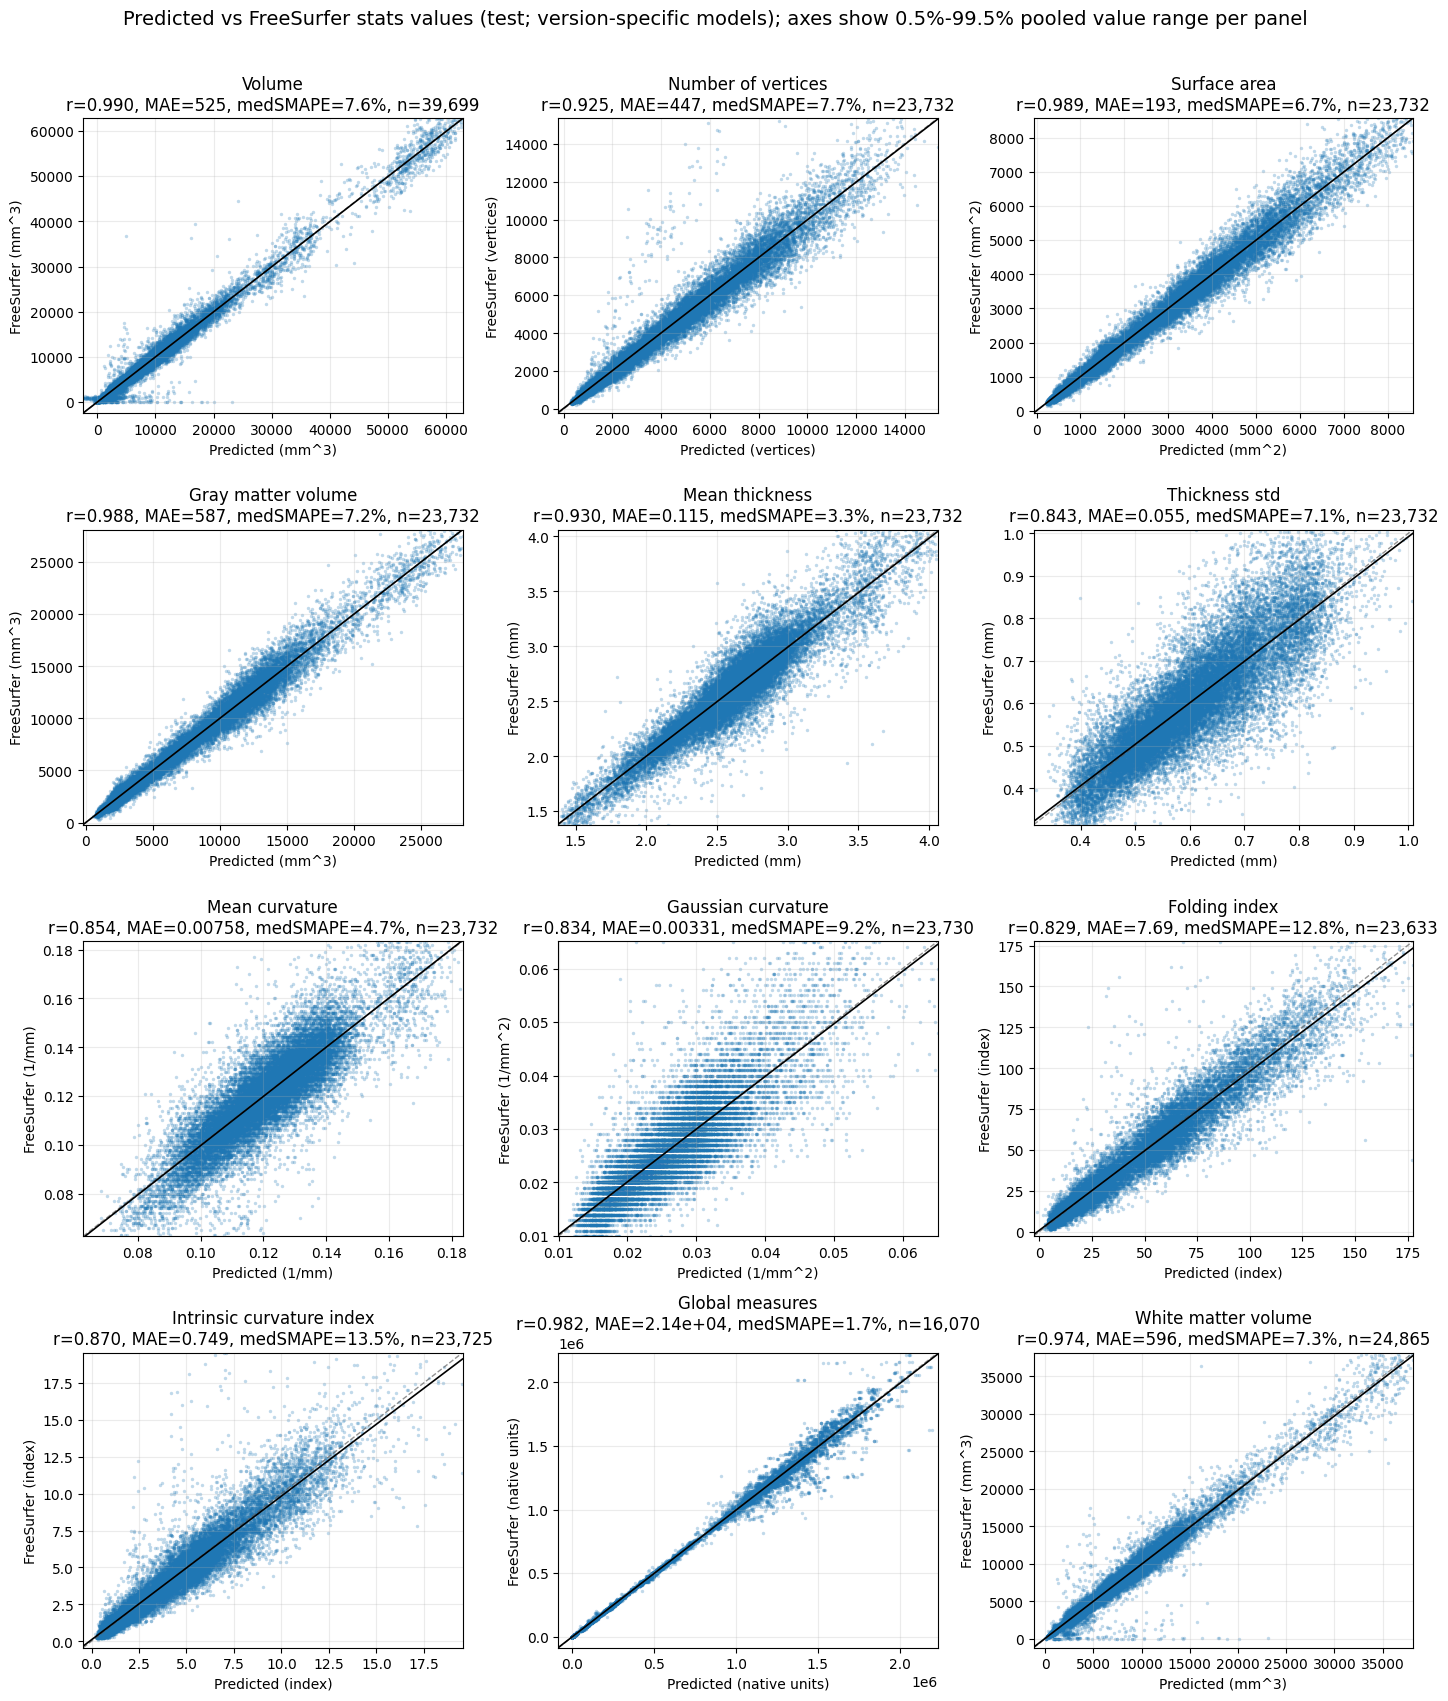

In [22]:
def _clean_stats_feature_scatter_data(feature_comparison: pd.DataFrame, measure: str) -> pd.DataFrame:
    data = feature_comparison.loc[
        feature_comparison['measure'].eq(measure),
        ['pred_value', 'fs_value'],
    ].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    data = data[np.isfinite(data['pred_value']) & np.isfinite(data['fs_value'])]
    return data


def _robust_xy_limits(x: np.ndarray, y: np.ndarray, *, quantiles=SCATTER_AXIS_QUANTILES) -> tuple[float, float, int]:
    finite = np.isfinite(x) & np.isfinite(y)
    if not finite.any():
        return 0.0, 1.0, 0
    xy = np.concatenate([x[finite], y[finite]])
    if bool(SCATTER_ROBUST_AXES) and xy.size >= 20:
        lo, hi = np.nanquantile(xy, quantiles)
    else:
        lo, hi = np.nanmin(xy), np.nanmax(xy)
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = np.nanmin(xy), np.nanmax(xy)
    if hi - lo < float(SCATTER_MIN_AXIS_SPAN):
        center = 0.5 * (hi + lo)
        lo = center - 0.5
        hi = center + 0.5
    pad = 0.04 * max(float(hi - lo), float(SCATTER_MIN_AXIS_SPAN))
    lo -= pad
    hi += pad
    if lo > 0 and lo < 0.08 * max(hi, 1e-12):
        lo = 0.0
    clipped = int(np.sum(finite & ((x < lo) | (x > hi) | (y < lo) | (y > hi))))
    return float(lo), float(hi), clipped


def stats_feature_correlation_table(feature_comparison: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for measure, data in feature_comparison.groupby('measure'):
        clean = _clean_stats_feature_scatter_data(feature_comparison, measure)
        if clean.empty:
            continue
        x = clean['pred_value'].to_numpy(dtype=np.float64)
        y = clean['fs_value'].to_numpy(dtype=np.float64)
        r = np.nan
        if len(clean) >= 2 and np.unique(x).size > 1 and np.unique(y).size > 1:
            r = float(np.corrcoef(x, y)[0, 1])
        abs_err = np.abs(x - y)
        smape = 200.0 * abs_err / (np.abs(x) + np.abs(y) + 1e-8)
        rows.append({
            'measure': measure,
            'label': MEASURE_LABELS.get(measure, measure),
            'unit': _measure_unit(measure),
            'n': int(len(clean)),
            'pearson_r': r,
            'mae': float(np.mean(abs_err)),
            'rmse': float(np.sqrt(np.mean((x - y) ** 2))),
            'median_smape_pct': float(np.median(smape)),
        })
    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary['_measure_order'] = summary['measure'].map(MEASURE_ORDER).fillna(99)
        summary = summary.sort_values(['_measure_order', 'measure']).drop(columns='_measure_order').reset_index(drop=True)
    return summary


def _plot_one_stats_feature_scatter(ax, feature_comparison: pd.DataFrame, row: pd.Series, *, point_size=6, alpha=0.28):
    measure = row['measure']
    data = _clean_stats_feature_scatter_data(feature_comparison, measure)
    if data.empty:
        ax.set_axis_off()
        return
    if SCATTER_MAX_POINTS_PER_PANEL and len(data) > SCATTER_MAX_POINTS_PER_PANEL:
        data = data.sample(int(SCATTER_MAX_POINTS_PER_PANEL), random_state=SEED)

    x = data['pred_value'].to_numpy(dtype=np.float64)
    y = data['fs_value'].to_numpy(dtype=np.float64)
    ax.scatter(x, y, s=point_size, alpha=alpha, linewidths=0)

    finite = np.isfinite(x) & np.isfinite(y)
    lo, hi, clipped = _robust_xy_limits(x, y)
    if finite.sum() >= 2:
        ax.plot([lo, hi], [lo, hi], color='0.35', linestyle='--', linewidth=1.0, alpha=0.65)
        fit_mask = finite & (x >= lo) & (x <= hi) & (y >= lo) & (y <= hi)
        if fit_mask.sum() >= 2 and np.unique(x[fit_mask]).size > 1:
            fit = np.polyfit(x[fit_mask], y[fit_mask], 1)
            xs = np.linspace(lo, hi, 100)
            ax.plot(xs, fit[0] * xs + fit[1], color='k', linewidth=1.2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    r = row.get('pearson_r', np.nan)
    n = int(row.get('n', len(data)))
    mae = row.get('mae', np.nan)
    smape = row.get('median_smape_pct', np.nan)
    title = row.get('label', measure)
    clipped_text = "" # f', clipped={clipped:,}' if clipped else ''
    ax.set_title(f'{title}\nr={r:.3f}, MAE={mae:.3g}, medSMAPE={smape:.1f}%, n={n:,}{clipped_text}')
    ax.set_xlabel(_axis_label('Predicted', measure))
    ax.set_ylabel(_axis_label('FreeSurfer', measure))
    ax.grid(True, alpha=0.25)


def plot_stats_feature_scatter_grid(
    feature_comparison: pd.DataFrame,
    *,
    summary: pd.DataFrame | None = None,
    max_cols: int = 3,
    figsize_per_panel=(4.8, 4.2),
    save_path: str | Path | None = None,
    title: str = 'Predicted vs FreeSurfer stats values',
):
    if summary is None:
        summary = stats_feature_correlation_table(feature_comparison)
    summary = summary.copy()
    summary = summary[summary['n'].fillna(0).astype(int) > 0]
    if summary.empty:
        raise ValueError('No stats feature-comparison rows available to plot.')

    n_panels = len(summary)
    n_cols = min(int(max_cols), n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )
    for ax, (_, row) in zip(axes.ravel(), summary.iterrows()):
        _plot_one_stats_feature_scatter(ax, feature_comparison, row)
    for ax in axes.ravel()[n_panels:]:
        ax.set_axis_off()

    if SCATTER_ROBUST_AXES:
        title = f'{title}; axes show {SCATTER_AXIS_QUANTILES[0]:.1%}-{SCATTER_AXIS_QUANTILES[1]:.1%} pooled value range per panel'
    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved:', save_path)
    return fig, summary


WMPARC_VOLUME_MEASURE = 'WMPARC_Volume_mm3'
MEASURE_ORDER.setdefault(WMPARC_VOLUME_MEASURE, max(MEASURE_ORDER.values()) + 1)
MEASURE_LABELS.setdefault(WMPARC_VOLUME_MEASURE, 'White matter volume')
MEASURE_UNITS.setdefault(WMPARC_VOLUME_MEASURE, 'mm^3')


def add_wmparc_volume_subplot_rows(feature_comparison: pd.DataFrame) -> pd.DataFrame:
    out = feature_comparison.copy()
    if 'stats_name' in out.columns:
        stats_name = out['stats_name'].astype(str)
    else:
        stats_name = out['target'].map(lambda value: str(value).split(':', 1)[0])
    wmparc_volume = out[stats_name.eq('wmparc') & out['measure'].eq('Volume_mm3')].copy()
    if wmparc_volume.empty:
        print('No wmparc Volume_mm3 rows available for the extra scatter subplot.')
        return out
    wmparc_volume['measure'] = WMPARC_VOLUME_MEASURE
    return pd.concat([out, wmparc_volume], ignore_index=True)


feature_comparison_for_grid = add_wmparc_volume_subplot_rows(feature_comparison_best)
stats_feature_scatter_summary = stats_feature_correlation_table(feature_comparison_for_grid)
stats_feature_scatter_fig, stats_feature_scatter_summary = plot_stats_feature_scatter_grid(
    feature_comparison_for_grid,
    summary=stats_feature_scatter_summary,
    max_cols=3,
    #save_path=SCATTER_FIG_PATH,
    save_path="/home/rph/scalesurfer/docs/notebooks/03_inference/stats_feature_predictions_by_measure_canonical_aparc_clean_v5_sum_poolstats_test.svg",
    title=f'Predicted vs FreeSurfer stats values ({SCATTER_SPLIT}; version-specific models)',
)
display(stats_feature_scatter_summary)


## 10. FreeSurfer Agreement Diagnostics

Scatter plots show association, but FreeSurfer users usually care about agreement: signed bias, limits of agreement, reliability, and whether the error is small enough for downstream morphometry. This section adds FreeSurfer-facing diagnostics that use the saved feature-comparison table when it already exists, so rerunning these cells does not rebuild predictions.

The practical tolerance thresholds below are deliberately explicit and editable. They are not universal clinical acceptability thresholds; they are transparent defaults for asking, measure by measure, how often the model is close enough to FreeSurfer to be useful.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

if 'feature_comparison_best' not in globals() or feature_comparison_best is None or feature_comparison_best.empty:
    if not SCATTER_COMPARISON_PATH.exists():
        raise FileNotFoundError(
            f'Missing {SCATTER_COMPARISON_PATH}. Run the prediction-comparison cell first.'
        )
    feature_comparison_best = pd.read_csv(SCATTER_COMPARISON_PATH)
    print('loaded:', SCATTER_COMPARISON_PATH)

AGREEMENT_SUMMARY_PATH = OUT_ROOT / f'stats_agreement_summary_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.csv'
TARGET_AGREEMENT_PATH = OUT_ROOT / f'stats_target_agreement_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.csv'
STAGE_AGREEMENT_PATH = OUT_ROOT / f'stats_stage_measure_agreement_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.csv'
AGREEMENT_FIG_PATH = BASE_PATH / 'docs/notebooks/03_inference' / f'stats_agreement_summary_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.png'
BLAND_ALTMAN_FIG_PATH = BASE_PATH / 'docs/notebooks/03_inference' / f'stats_bland_altman_by_measure_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.png'
CORTICAL_HEATMAP_FIG_PATH = BASE_PATH / 'docs/notebooks/03_inference' / f'stats_cortical_region_measure_error_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.png'
STAGE_HEATMAP_FIG_PATH = BASE_PATH / 'docs/notebooks/03_inference' / f'stats_version_measure_smape_{TARGET_CACHE_TAG}_{SCATTER_SPLIT}.png'

PRACTICAL_ABS_TOLERANCE = {
    'Volume_mm3': 1000.0,
    'SurfArea': 250.0,
    'GrayVol': 1000.0,
    'ThickAvg': 0.20,
    'ThickStd': 0.10,
    'MeanCurv': 0.010,
    'GausCurv': 0.005,
    'FoldInd': 25.0,
    'CurvInd': 2.0,
    'NumVert': 500.0,
}
PRACTICAL_SMAPE_TOLERANCE = {
    'Volume_mm3': 10.0,
    'SurfArea': 10.0,
    'GrayVol': 10.0,
    'ThickAvg': 7.5,
    'ThickStd': 12.5,
    'MeanCurv': 10.0,
    'GausCurv': 15.0,
    'FoldInd': 20.0,
    'CurvInd': 20.0,
    'Global': 5.0,
    'NumVert': 10.0,
}


def _measure_sort_frame(frame: pd.DataFrame) -> pd.DataFrame:
    measure_order = globals().get('MEASURE_ORDER', {})
    out = frame.copy()
    out['_measure_order'] = out['measure'].map(measure_order).fillna(99)
    sort_cols = ['_measure_order'] + [col for col in ['measure', 'stage', 'target'] if col in out.columns]
    return out.sort_values(sort_cols).drop(columns='_measure_order').reset_index(drop=True)


def _measure_label(measure: str) -> str:
    return globals().get('MEASURE_LABELS', {}).get(measure, measure)


def _clean_stats_agreement_frame(feature_comparison: pd.DataFrame) -> pd.DataFrame:
    needed = ['stage', 'sample_id', 'group', 'target', 'measure', 'region', 'pred_value', 'fs_value']
    present = [col for col in needed if col in feature_comparison.columns]
    data = feature_comparison[present].copy()
    data['pred_value'] = pd.to_numeric(data['pred_value'], errors='coerce')
    data['fs_value'] = pd.to_numeric(data['fs_value'], errors='coerce')
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=['pred_value', 'fs_value', 'measure'])
    data = data[np.isfinite(data['pred_value']) & np.isfinite(data['fs_value'])].copy()
    data['error'] = data['pred_value'] - data['fs_value']
    data['abs_error'] = data['error'].abs()
    data['mean_value'] = 0.5 * (data['pred_value'] + data['fs_value'])
    data['smape_pct'] = 200.0 * data['abs_error'] / (data['pred_value'].abs() + data['fs_value'].abs() + 1e-8)
    data['abs_tolerance'] = data['measure'].map(PRACTICAL_ABS_TOLERANCE)
    data['smape_tolerance'] = data['measure'].map(PRACTICAL_SMAPE_TOLERANCE)
    data['within_abs_tolerance'] = data['abs_tolerance'].notna() & (data['abs_error'] <= data['abs_tolerance'])
    data['within_smape_tolerance'] = data['smape_tolerance'].notna() & (data['smape_pct'] <= data['smape_tolerance'])
    data['within_practical_tolerance'] = data['within_abs_tolerance'] | data['within_smape_tolerance']
    return data


def _pearson_r(x, y) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 2 or np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _icc_a1(fs_values, pred_values) -> float:
    """Two-way mixed, absolute-agreement, single-measure ICC(A,1)."""
    fs_values = np.asarray(fs_values, dtype=np.float64)
    pred_values = np.asarray(pred_values, dtype=np.float64)
    mask = np.isfinite(fs_values) & np.isfinite(pred_values)
    ratings = np.column_stack([fs_values[mask], pred_values[mask]])
    n, k = ratings.shape if ratings.size else (0, 2)
    if n < 3:
        return np.nan
    row_mean = ratings.mean(axis=1, keepdims=True)
    col_mean = ratings.mean(axis=0, keepdims=True)
    grand_mean = float(ratings.mean())
    ms_rows = float(k * np.sum((row_mean - grand_mean) ** 2) / (n - 1))
    ms_cols = float(n * np.sum((col_mean - grand_mean) ** 2) / (k - 1))
    residual = ratings - row_mean - col_mean + grand_mean
    ms_error = float(np.sum(residual ** 2) / ((n - 1) * (k - 1)))
    denom = ms_rows + (k - 1) * ms_error + (k * (ms_cols - ms_error) / n)
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return np.nan
    return float((ms_rows - ms_error) / denom)


def stats_agreement_table(feature_comparison: pd.DataFrame, group_cols=('measure',)) -> pd.DataFrame:
    data = _clean_stats_agreement_frame(feature_comparison)
    rows = []
    for keys, frame in data.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        pred = frame['pred_value'].to_numpy(dtype=np.float64)
        fs = frame['fs_value'].to_numpy(dtype=np.float64)
        error = pred - fs
        abs_error = np.abs(error)
        smape = frame['smape_pct'].to_numpy(dtype=np.float64)
        bias = float(np.mean(error))
        sd_error = float(np.std(error, ddof=1)) if len(error) > 1 else np.nan
        row.update({
            'label': _measure_label(row['measure']) if 'measure' in row else '',
            'n': int(len(frame)),
            'pearson_r': _pearson_r(pred, fs),
            'icc_a1': _icc_a1(fs, pred),
            'bias_pred_minus_fs': bias,
            'loa95_low': bias - 1.96 * sd_error if np.isfinite(sd_error) else np.nan,
            'loa95_high': bias + 1.96 * sd_error if np.isfinite(sd_error) else np.nan,
            'mae': float(np.mean(abs_error)),
            'rmse': float(np.sqrt(np.mean(error ** 2))),
            'median_abs_error': float(np.median(abs_error)),
            'p95_abs_error': float(np.percentile(abs_error, 95)),
            'median_smape_pct': float(np.median(smape)),
            'p95_smape_pct': float(np.percentile(smape, 95)),
            'within_5pct_smape': 100.0 * float(np.mean(smape <= 5.0)),
            'within_10pct_smape': 100.0 * float(np.mean(smape <= 10.0)),
            'within_20pct_smape': 100.0 * float(np.mean(smape <= 20.0)),
            'within_practical_tolerance': 100.0 * float(frame['within_practical_tolerance'].mean()),
        })
        rows.append(row)
    out = pd.DataFrame(rows)
    if 'measure' in out.columns:
        out = _measure_sort_frame(out)
    return out


def stats_target_agreement_table(feature_comparison: pd.DataFrame) -> pd.DataFrame:
    data = _clean_stats_agreement_frame(feature_comparison)
    rows = []
    group_cols = ['group', 'target', 'measure', 'region']
    for keys, frame in data.groupby(group_cols, dropna=False):
        pred = frame['pred_value'].to_numpy(dtype=np.float64)
        fs = frame['fs_value'].to_numpy(dtype=np.float64)
        error = pred - fs
        abs_error = np.abs(error)
        rows.append({
            **dict(zip(group_cols, keys)),
            'n': int(len(frame)),
            'pearson_r': _pearson_r(pred, fs),
            'icc_a1': _icc_a1(fs, pred),
            'bias_pred_minus_fs': float(np.mean(error)),
            'mae': float(np.mean(abs_error)),
            'median_abs_error': float(np.median(abs_error)),
            'median_smape_pct': float(np.median(frame['smape_pct'])),
            'p95_smape_pct': float(np.percentile(frame['smape_pct'], 95)),
            'within_practical_tolerance': 100.0 * float(frame['within_practical_tolerance'].mean()),
        })
    return _measure_sort_frame(pd.DataFrame(rows))


agreement_frame = _clean_stats_agreement_frame(feature_comparison_best)
stats_agreement_summary = stats_agreement_table(feature_comparison_best)
stats_stage_agreement_summary = stats_agreement_table(feature_comparison_best, group_cols=('stage', 'measure'))
stats_target_agreement = stats_target_agreement_table(feature_comparison_best)

stats_agreement_summary.to_csv(AGREEMENT_SUMMARY_PATH, index=False)
stats_stage_agreement_summary.to_csv(STAGE_AGREEMENT_PATH, index=False)
stats_target_agreement.to_csv(TARGET_AGREEMENT_PATH, index=False)
print('wrote:', AGREEMENT_SUMMARY_PATH)
print('wrote:', STAGE_AGREEMENT_PATH)
print('wrote:', TARGET_AGREEMENT_PATH)

display(stats_agreement_summary)
display(stats_target_agreement.sort_values(['median_smape_pct', 'mae'], ascending=False).head(25))


wrote: /home/rph/scalesurfer/data/stats_prediction/stats_agreement_summary_canonical_aparc_clean_v5_sum_poolstats_test.csv
wrote: /home/rph/scalesurfer/data/stats_prediction/stats_stage_measure_agreement_canonical_aparc_clean_v5_sum_poolstats_test.csv
wrote: /home/rph/scalesurfer/data/stats_prediction/stats_target_agreement_canonical_aparc_clean_v5_sum_poolstats_test.csv


,measure,label,n,pearson_r,icc_a1,bias_pred_minus_fs,loa95_low,loa95_high,mae,rmse,median_abs_error,p95_abs_error,median_smape_pct,p95_smape_pct,within_5pct_smape,within_10pct_smape,within_20pct_smape,within_practical_tolerance
0,Volume_mm3,Volume,39699,0.990015,0.989796,-18.196544,-2583.604687,2547.211599,525.303695,1308.991703,234.573730,1874.042773,7.646717,60.693187,34.912718,60.243331,83.420237,90.372553
1,NumVert,Number of vertices,23732,0.925482,0.914065,-101.066967,-2764.816713,2562.682778,446.612128,1362.780207,206.776489,1262.490369,7.741508,27.063285,33.819316,61.090511,88.644025,82.331873
2,SurfArea,Surface area,23732,0.988665,0.988572,-5.521701,-572.376991,561.333589,192.939949,289.258496,121.028900,621.208215,6.738505,22.449704,38.247935,67.861959,92.714478,84.409236
3,GrayVol,Gray matter volume,23732,0.987947,0.987840,-9.010153,-1723.805091,1705.784785,587.139416,874.923339,370.636230,1883.005420,7.225632,25.286170,36.157930,64.044328,90.148323,86.848980
4,ThickAvg,Mean thickness,23732,0.929546,0.926663,0.002922,-0.310765,0.316610,0.114557,0.160068,0.083998,0.326554,3.272010,12.099119,67.727120,91.479858,99.064554,85.846115
5,ThickStd,Thickness std,23732,0.843060,0.829544,-0.002310,-0.149064,0.144445,0.054991,0.074909,0.041045,0.154391,7.054683,24.450018,37.266139,64.924996,90.830946,85.631215
6,MeanCurv,Mean curvature,23732,0.853799,0.834472,0.000297,-0.020596,0.021189,0.007585,0.010663,0.005597,0.021080,4.659852,17.750554,53.046519,81.038261,96.304568,81.573403
7,GausCurv,Gaussian curvature,23730,0.833873,0.813180,-0.000189,-0.010536,0.010157,0.003310,0.005282,0.002251,0.009703,9.237654,33.459485,29.553308,53.253266,82.170249,81.647703
8,FoldInd,Folding index,23633,0.829302,0.789989,-1.127478,-54.175524,51.920568,7.688979,27.088232,3.993271,19.760381,12.750018,48.190957,21.338806,40.917361,69.102526,97.291922
9,CurvInd,Intrinsic curvature index,23725,0.869748,0.838540,-0.130316,-4.429937,4.169304,0.749331,2.197505,0.365936,2.063071,13.494650,50.256683,20.126449,38.748156,66.731296,95.144362


,group,target,measure,region,n,pearson_r,icc_a1,bias_pred_minus_fs,mae,median_abs_error,median_smape_pct,p95_smape_pct,within_practical_tolerance
2,aseg,aseg:5th-Ventricle:Volume_mm3,Volume_mm3,5th-Ventricle,363,0.109532,0.012106,-0.045600,0.109495,0.033435,199.999934,199.999976,100.000000
42,aseg,aseg:non-WM-hypointensities:Volume_mm3,Volume_mm3,non-WM-hypointensities,363,0.069858,0.008355,-0.037791,0.065835,0.012428,199.999829,199.999966,100.000000
87,aseg,wmparc:wm-rh-corpuscallosum:Volume_mm3,Volume_mm3,wm-rh-corpuscallosum,13,0.132659,0.021717,-18.223753,46.246354,32.968853,127.620934,188.919926,100.000000
9,aseg,aseg:CSF:Volume_mm3,Volume_mm3,CSF,315,0.214055,0.053581,171.953906,1457.290588,1124.128906,88.702833,200.000000,43.809524
40,aseg,aseg:Right-vessel:Volume_mm3,Volume_mm3,Right-vessel,363,0.501801,0.362703,-2.255559,9.595503,6.519526,54.710855,200.000000,100.000000
24,aseg,aseg:Left-vessel:Volume_mm3,Volume_mm3,Left-vessel,363,0.570897,0.459765,-2.331479,12.949585,9.402355,52.997170,200.000000,100.000000
41,aseg,aseg:WM-hypointensities:Volume_mm3,Volume_mm3,WM-hypointensities,362,0.586042,0.296666,-49.796110,434.166754,263.186127,32.036374,188.341299,95.580110
752,global,aseg:global:rhSurfaceHoles,Global,rhSurfaceHoles,315,0.773423,0.698787,-0.241269,7.423539,4.782368,31.284557,115.826972,9.841270
749,global,aseg:global:lhSurfaceHoles,Global,lhSurfaceHoles,315,0.768471,0.687159,-0.718650,7.768763,5.207806,30.395036,102.086391,10.476190
633,rh_aparc,rh.aparc:entorhinal:FoldInd,FoldInd,entorhinal,348,0.639755,0.343198,-0.186825,2.564655,1.784330,30.384798,87.499665,99.425287


saved: /home/rph/scalesurfer/docs/notebooks/03_inference/stats_agreement_summary_canonical_aparc_clean_v5_sum_poolstats_test.png
saved: /home/rph/scalesurfer/docs/notebooks/03_inference/stats_bland_altman_by_measure_canonical_aparc_clean_v5_sum_poolstats_test.png
saved: /home/rph/scalesurfer/docs/notebooks/03_inference/stats_version_measure_smape_canonical_aparc_clean_v5_sum_poolstats_test.png
saved: /home/rph/scalesurfer/docs/notebooks/03_inference/stats_cortical_region_measure_error_canonical_aparc_clean_v5_sum_poolstats_test.png


measure,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,MeanCurv,GausCurv,FoldInd,CurvInd
hemi_region,,,,,,,,,
lh:bankssts,9.542437,8.756402,10.330698,3.529909,8.539336,6.772297,11.835926,22.605880,17.432889
rh:bankssts,8.899951,7.532792,9.719725,3.682218,8.953465,7.567858,11.770942,23.206377,16.082663
lh:caudalanteriorcingulate,10.905894,11.555568,14.396801,4.576526,13.004414,7.051547,15.368649,22.246943,23.763248
rh:caudalanteriorcingulate,11.547790,11.364225,13.624306,5.283724,13.057103,5.480877,13.493990,19.476913,21.444688
lh:caudalmiddlefrontal,9.104114,8.295499,8.804401,2.720701,7.002424,3.974212,8.374968,14.754801,14.228858


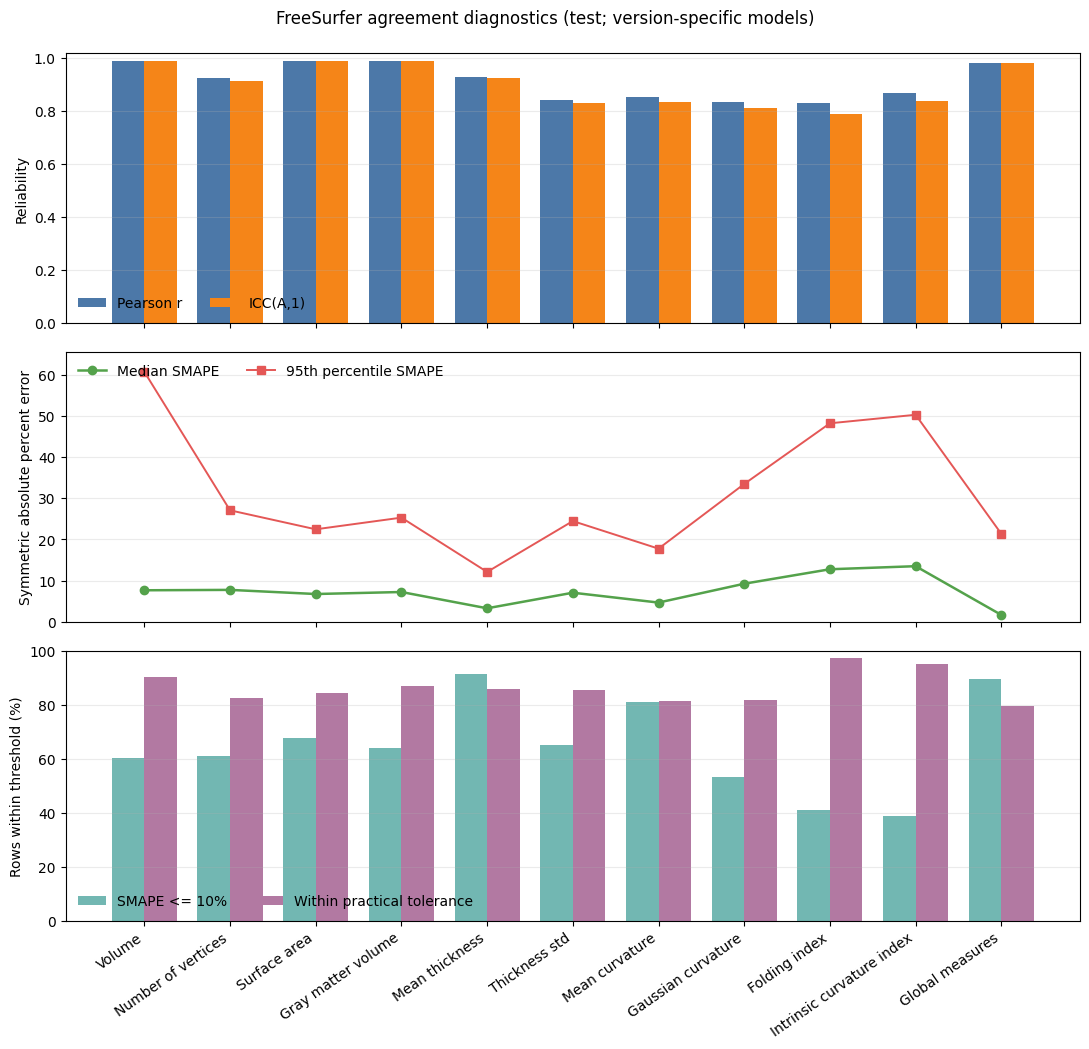

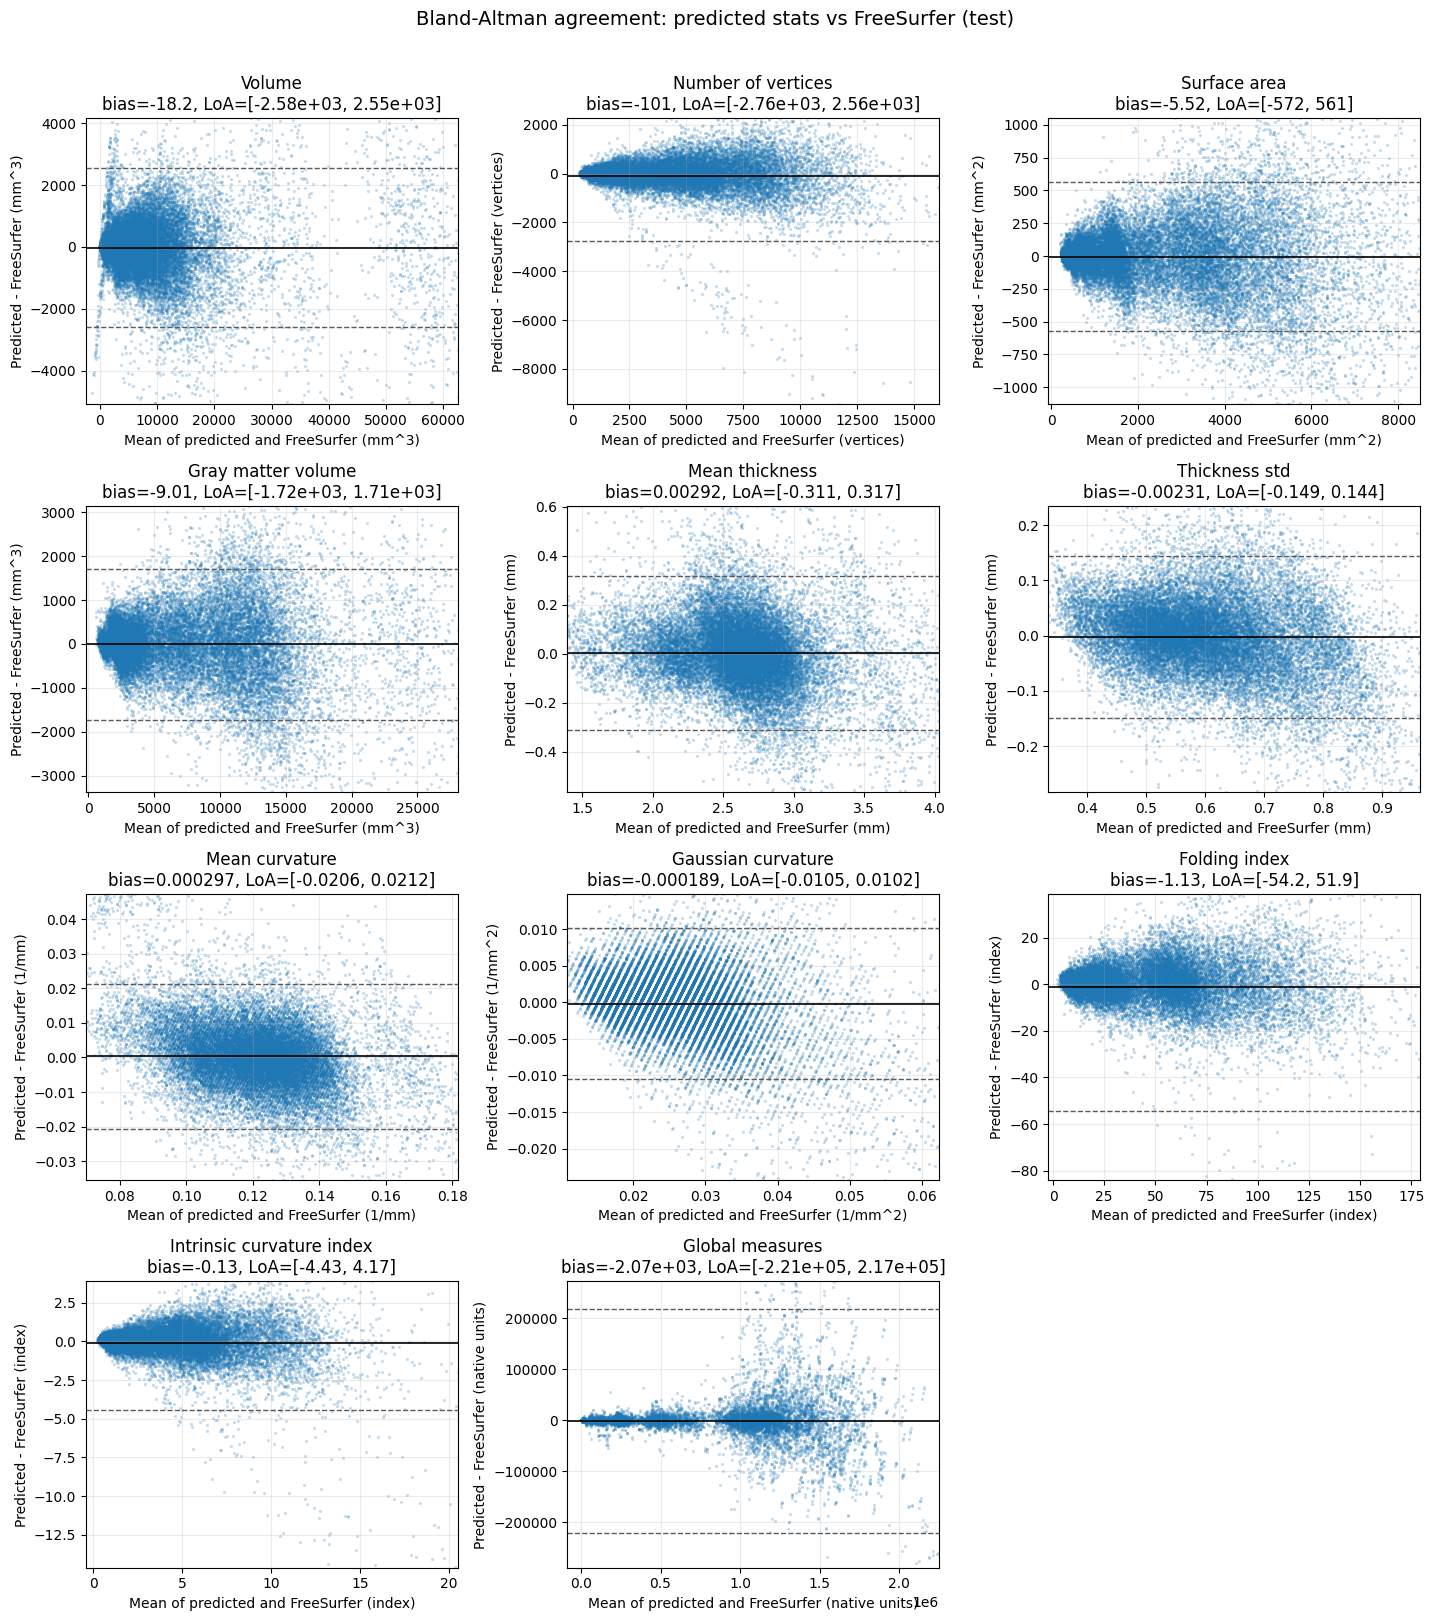

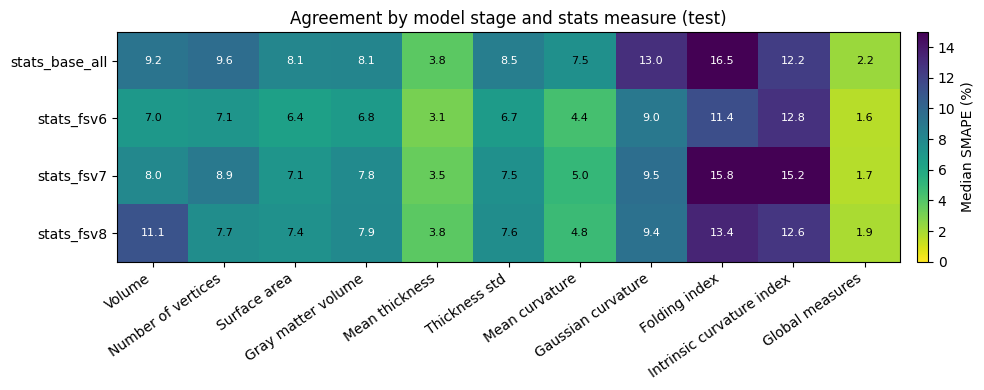

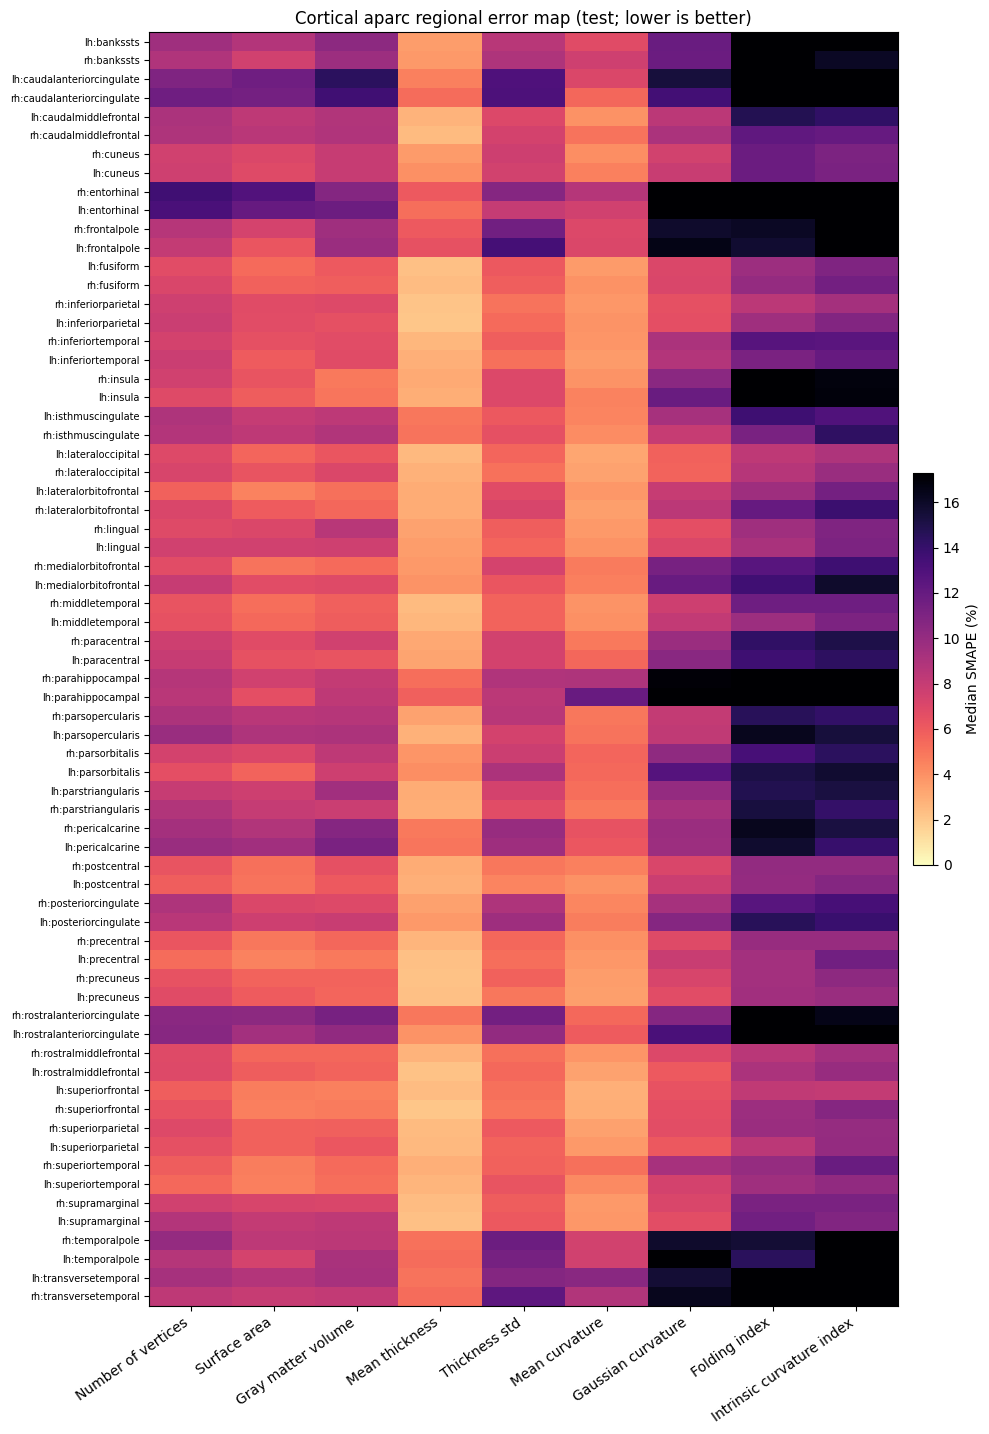

In [20]:
def plot_stats_agreement_summary(summary: pd.DataFrame, *, save_path=None):
    summary = _measure_sort_frame(summary).copy()
    labels = summary['label'].fillna(summary['measure']).to_list()
    x = np.arange(len(summary))
    fig, axes = plt.subplots(3, 1, figsize=(max(11, 0.72 * len(summary)), 10.5), sharex=True)

    width = 0.38
    axes[0].bar(x - width / 2, summary['pearson_r'], width=width, label='Pearson r', color='#4C78A8')
    axes[0].bar(x + width / 2, summary['icc_a1'], width=width, label='ICC(A,1)', color='#F58518')
    axes[0].set_ylim(0, 1.02)
    axes[0].set_ylabel('Reliability')
    axes[0].legend(loc='lower left', ncols=2, frameon=False)
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].plot(x, summary['median_smape_pct'], marker='o', linewidth=1.8, label='Median SMAPE', color='#54A24B')
    axes[1].plot(x, summary['p95_smape_pct'], marker='s', linewidth=1.4, label='95th percentile SMAPE', color='#E45756')
    axes[1].set_ylabel('Symmetric absolute percent error')
    axes[1].set_ylim(0, min(205, max(25, float(summary['p95_smape_pct'].max()) * 1.08)))
    axes[1].legend(loc='upper left', ncols=2, frameon=False)
    axes[1].grid(axis='y', alpha=0.25)

    axes[2].bar(x - width / 2, summary['within_10pct_smape'], width=width, label='SMAPE <= 10%', color='#72B7B2')
    axes[2].bar(x + width / 2, summary['within_practical_tolerance'], width=width, label='Within practical tolerance', color='#B279A2')
    axes[2].set_ylabel('Rows within threshold (%)')
    axes[2].set_ylim(0, 100)
    axes[2].legend(loc='lower left', ncols=2, frameon=False)
    axes[2].grid(axis='y', alpha=0.25)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=35, ha='right')

    fig.suptitle(f'FreeSurfer agreement diagnostics ({SCATTER_SPLIT}; version-specific models)', y=0.995)
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved:', save_path)
    return fig


BLAND_ALTMAN_ROBUST_AXES = True
BLAND_ALTMAN_AXIS_QUANTILES = (0.005, 0.995)


def _plot_one_bland_altman(ax, agreement: pd.DataFrame, row: pd.Series, *, max_points=50_000):
    data = agreement[agreement['measure'].eq(row['measure'])].copy()
    if data.empty:
        ax.set_axis_off()
        return
    if max_points and len(data) > max_points:
        data = data.sample(int(max_points), random_state=SEED)
    ax.scatter(data['mean_value'], data['error'], s=5, alpha=0.25, linewidths=0)
    measure = row['measure']
    bias = float(row['bias_pred_minus_fs'])
    loa_low = float(row['loa95_low'])
    loa_high = float(row['loa95_high'])
    ax.axhline(bias, color='k', linewidth=1.2, label='bias')
    ax.axhline(loa_low, color='0.35', linestyle='--', linewidth=1.0)
    ax.axhline(loa_high, color='0.35', linestyle='--', linewidth=1.0)
    clipped = 0
    if BLAND_ALTMAN_ROBUST_AXES and len(data) >= 20:
        xlo, xhi = np.nanquantile(data['mean_value'], BLAND_ALTMAN_AXIS_QUANTILES)
        ylo, yhi = np.nanquantile(data['error'], BLAND_ALTMAN_AXIS_QUANTILES)
        xpad = 0.04 * max(float(xhi - xlo), 1e-6)
        ypad = 0.04 * max(float(yhi - ylo), 1e-6)
        xlo, xhi = float(xlo - xpad), float(xhi + xpad)
        ylo, yhi = float(ylo - ypad), float(yhi + ypad)
        clipped = int(((data['mean_value'] < xlo) | (data['mean_value'] > xhi) | (data['error'] < ylo) | (data['error'] > yhi)).sum())
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(ylo, yhi)
    clipped_text = ""#f', clipped={clipped:,}' if clipped else ''
    ax.set_title(
        f"{row.get('label', row['measure'])}\n"
        f"bias={bias:.3g}, LoA=[{loa_low:.3g}, {loa_high:.3g}]{clipped_text}"
    )
    ax.set_xlabel(_axis_label('Mean of predicted and FreeSurfer', measure))
    ax.set_ylabel(_axis_label('Predicted - FreeSurfer', measure))
    ax.grid(True, alpha=0.25)


def plot_bland_altman_grid(feature_comparison: pd.DataFrame, summary: pd.DataFrame, *, save_path=None, max_cols=3):
    agreement = _clean_stats_agreement_frame(feature_comparison)
    summary = _measure_sort_frame(summary)
    n_panels = len(summary)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.0 * n_rows), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), summary.iterrows()):
        _plot_one_bland_altman(ax, agreement, row)
    for ax in axes.ravel()[n_panels:]:
        ax.set_axis_off()
    fig.suptitle(f'Bland-Altman agreement: predicted stats vs FreeSurfer ({SCATTER_SPLIT})', y=1.01, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved:', save_path)
    return fig


def plot_stage_measure_smape_heatmap(stage_summary: pd.DataFrame, *, save_path=None):
    stage_order = ['stats_base_all', 'stats_fsv6', 'stats_fsv7', 'stats_fsv8']
    measure_order = list(globals().get('MEASURE_ORDER', {}).keys())
    data = stage_summary.copy()
    table = data.pivot_table(index='stage', columns='measure', values='median_smape_pct', aggfunc='mean')
    table = table.reindex([stage for stage in stage_order if stage in table.index])
    table = table.reindex([m for m in measure_order if m in table.columns], axis=1)
    values = table.to_numpy(dtype=np.float64)

    fig, ax = plt.subplots(figsize=(max(10, 0.85 * table.shape[1]), max(2.8, 0.55 * table.shape[0] + 1.8)))
    image = ax.imshow(values, aspect='auto', cmap='viridis_r', vmin=0, vmax=np.nanpercentile(values, 95))
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels([_measure_label(m) for m in table.columns], rotation=35, ha='right')
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, f'{value:.1f}', ha='center', va='center', fontsize=8, color='white' if value > np.nanmedian(values) else 'black')
    cbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Median SMAPE (%)')
    ax.set_title(f'Agreement by model stage and stats measure ({SCATTER_SPLIT})')
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved:', save_path)
    return fig


def plot_cortical_region_measure_error_heatmap(feature_comparison: pd.DataFrame, *, save_path=None):
    data = _clean_stats_agreement_frame(feature_comparison)
    data = data[data['group'].isin(['lh_aparc', 'rh_aparc'])].copy()
    data = data[data['measure'].isin([m for m in globals().get('MEASURE_ORDER', {}) if m != 'Global'])]
    if data.empty:
        raise ValueError('No cortical aparc rows available for the region-measure heatmap.')
    data['hemi_region'] = data['group'].str.replace('_aparc', '', regex=False) + ':' + data['region'].astype(str)
    table = data.pivot_table(index='hemi_region', columns='measure', values='smape_pct', aggfunc='median')
    measure_order = [m for m in globals().get('MEASURE_ORDER', {}) if m in table.columns and m != 'Global']
    table = table.reindex(measure_order, axis=1)
    table = table.sort_index(key=lambda idx: idx.str.replace('lh:', '').str.replace('rh:', ''))
    values = table.to_numpy(dtype=np.float64)

    fig_height = max(8, 0.18 * table.shape[0] + 2.2)
    fig, ax = plt.subplots(figsize=(max(10, 0.9 * table.shape[1]), fig_height))
    vmax = max(10, np.nanpercentile(values, 95))
    image = ax.imshow(values, aspect='auto', cmap='magma_r', vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels([_measure_label(m) for m in table.columns], rotation=35, ha='right')
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index, fontsize=7)
    cbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Median SMAPE (%)')
    ax.set_title(f'Cortical aparc regional error map ({SCATTER_SPLIT}; lower is better)')
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved:', save_path)
    return fig, table


stats_agreement_fig = plot_stats_agreement_summary(stats_agreement_summary, save_path=AGREEMENT_FIG_PATH)
stats_bland_altman_fig = plot_bland_altman_grid(feature_comparison_best, stats_agreement_summary, save_path=BLAND_ALTMAN_FIG_PATH)
stats_stage_heatmap_fig = plot_stage_measure_smape_heatmap(stats_stage_agreement_summary, save_path=STAGE_HEATMAP_FIG_PATH)
stats_cortical_heatmap_fig, stats_cortical_region_smape = plot_cortical_region_measure_error_heatmap(
    feature_comparison_best,
    save_path=CORTICAL_HEATMAP_FIG_PATH,
)
display(stats_cortical_region_smape.head())
